<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 10 - Uncertainty and Conformal Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Uncertainty and Conformal Prediction

A model that predicts a claim cost of 2,300 € is useful. A model that says "between 900 € and 6,000 €, with probability 90%" is far more useful: the reserve, the price loading, the decision to send an expert and the triage of a patient all depend on how wrong the prediction can be, not only on its value. Most models of the course return one number per input. This lab is about the rest of the answer.

We first look at how a model can express its uncertainty: predicting a whole distribution, predicting quantiles, disagreeing with itself (ensembles), and giving calibrated probabilities. None of these comes with a guarantee. Then we build **conformal prediction**, a thin wrapper around *any* model that turns it into intervals or sets of classes that contain the truth with a chosen probability, say 90%, in finite samples and without assumptions on the model or the distribution of the data. The only assumption is that the data are exchangeable, and the last section shows what happens when they are not.

**Contents**

1. Two kinds of uncertainty; prediction vs confidence intervals
2. Predicting a distribution: a heteroscedastic Gaussian network
3. Quantile regression and the pinball loss
4. Epistemic uncertainty: deep ensembles and MC dropout
5. Split conformal prediction from scratch
6. Conditional coverage: normalised scores and CQR
7. A real dataset: California housing
8. Classification: calibration, temperature scaling and prediction sets
9. When exchangeability breaks: distribution shift and adaptive conformal inference
10. Summary and exercises

This lab goes with the slides *Extra 10 · Uncertainty and conformal prediction* and uses the same notation. It assumes regression and classification as maximum likelihood (Gaussian ⇒ MSE, Bernoulli ⇒ cross-entropy), calibration and reliability diagrams (logistic-regression topic), train/validation/test splits, ensembles, dropout and the PyTorch training loop. Everything runs on a CPU: about 1 minute on this course's machine with 4 threads, a few minutes on a free Colab CPU; a GPU is not needed.

**Notation**

| Symbol | Meaning |
|---|---|
| $(X_i, Y_i)$ | examples; $\mathcal{D}_{\text{train}}$ fits the model, $\mathcal{D}_{\text{cal}}$ ($n$ points) calibrates it |
| $\hat\mu(x)$, $\hat\sigma(x)$ | predicted mean and predicted spread (standard deviation) of $Y \mid X = x$ |
| $\hat q_\tau(x)$, $\rho_\tau$ | predicted $\tau$-quantile of $Y \mid X = x$; the pinball loss that trains it |
| $\alpha$ | miscoverage level: the target coverage is $1 - \alpha$ ($\alpha = 0.1$ → 90%) |
| $s(x, y)$, $s_i$ | nonconformity score (large = unusual); the scores of the calibration points |
| $\hat q$ | conformal quantile: the $\lceil (n+1)(1-\alpha) \rceil$-th smallest of $s_1, \dots, s_n$ |
| $C(x)$ | prediction interval (regression) or prediction set (classification) |
| coverage | $P(Y \in C(X))$; marginal = averaged over $X$, conditional = at a given $x$ |
| $\hat p_k(x)$, $T$ | predicted probability of class $k$; temperature of the softmax |
| ECE | expected calibration error: average gap between confidence and accuracy |

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from scipy import stats, optimize
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| scikit-learn", sklearn.__version__)
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | scikit-learn 1.8.0


## 1. Two kinds of uncertainty

Two claims can have the same predicted cost and still be very different: one will almost surely land close to the prediction, the other could be ten times larger. Uncertainty has two sources.

- **Aleatoric** uncertainty is the noise in $Y$ given $X$: two policyholders with identical features still have different claims. It belongs to the data, and more data does not reduce it. It can change with $x$: **heteroscedastic** noise.
- **Epistemic** uncertainty is our lack of knowledge of the model: few data, regions never seen, a wrong model class. More data reduces it.

Our playground is a one-dimensional problem where we know the truth, so every interval can be checked:

$$
X \sim \mathcal{U}(0, 5), \qquad Y = f(X) + \sigma(X)\,\varepsilon, \qquad f(x) = 1.5\sin(1.4x) + 0.4x, \qquad \sigma(x) = 0.1 + 0.25x, \qquad \varepsilon \sim \mathcal{N}(0, 1).
$$

The noise standard deviation grows 13.5 times from $x = 0$ to $x = 5$. The noise is Gaussian, so the ideal 90% interval is $f(x) \pm 1.645\,\sigma(x)$, which we call the **true band** ($1.645$ is the 95% quantile of $\mathcal{N}(0,1)$). We draw 1,000 training points and a pool of 20,000 fresh points for calibration and testing, a luxury of synthetic data.

train: 1000 points, pool: 20000 points
noise sd: 0.10 at x = 0 and 1.35 at x = 5 (ratio 13.5)
pool points inside the true band f(x) ± 1.645 sigma(x): 0.899   (expected 0.900)


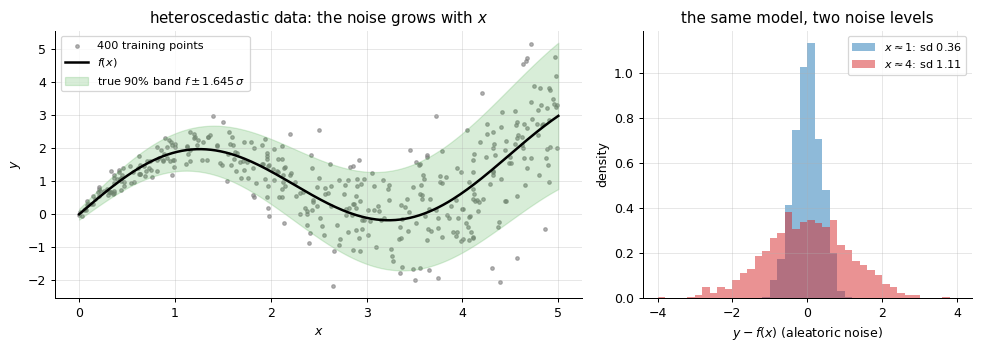

In [2]:
def f_true(x):
    # E[Y | X = x], the true regression function
    return 1.5 * np.sin(1.4 * x) + 0.4 * x

def sigma_true(x):
    # true noise standard deviation: it grows with x (heteroscedastic noise)
    return 0.1 + 0.25 * x

def make_data(n, rng, lo=0.0, hi=5.0, noise_mult=1.0):
    # n draws of X ~ U(lo, hi) and Y = f(X) + noise_mult * sigma(X) * N(0, 1)
    x = rng.uniform(lo, hi, n)
    y = f_true(x) + noise_mult * sigma_true(x) * rng.standard_normal(n)
    return x, y

rng = np.random.default_rng(0)
x_tr, y_tr = make_data(1000, rng)          # fits every model of sections 1 to 6
x_pool, y_pool = make_data(20000, rng)     # fresh points: calibration and test sets
z90 = stats.norm.ppf(0.95)                 # 1.645: mean ± 1.645 sd holds 90% of a Gaussian
xg = np.linspace(0, 5, 201)                # plotting grid
in_true = np.abs(y_pool - f_true(x_pool)) <= z90 * sigma_true(x_pool)

print(f"train: {len(x_tr)} points, pool: {len(x_pool)} points")
print(f"noise sd: {sigma_true(0):.2f} at x = 0 and {sigma_true(5):.2f} at x = 5 (ratio {sigma_true(5) / sigma_true(0):.1f})")
print(f"pool points inside the true band f(x) ± {z90:.3f} sigma(x): {in_true.mean():.3f}   (expected 0.900)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
ax.scatter(x_tr[:400], y_tr[:400], s=8, c="gray", alpha=0.6, label="400 training points")
ax.plot(xg, f_true(xg), "k", lw=2, label="$f(x)$")
ax.fill_between(xg, f_true(xg) - z90 * sigma_true(xg), f_true(xg) + z90 * sigma_true(xg),
                color="tab:green", alpha=0.18, label=r"true 90% band $f \pm 1.645\,\sigma$")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title("heteroscedastic data: the noise grows with $x$"); ax.legend(loc="upper left", fontsize=9)
ax = axes[1]
for x0, c in ((1.0, "tab:blue"), (4.0, "tab:red")):
    near = np.abs(x_pool - x0) < 0.1
    ax.hist(y_pool[near] - f_true(x_pool[near]), bins=np.linspace(-4, 4, 41), alpha=0.5, color=c, density=True,
            label=f"$x \\approx {x0:.0f}$: sd {np.std(y_pool[near] - f_true(x_pool[near])):.2f}")
ax.set_xlabel(r"$y - f(x)$ (aleatoric noise)"); ax.set_ylabel("density"); ax.set_title("the same model, two noise levels"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Things to notice.**
- The true band holds 0.899 of the 20,000 pool points, as it should: we know the data-generating process exactly, so every interval below can be judged against the truth.
- Near $x = 1$ the residuals $y - f(x)$ have a standard deviation of about 0.36, near $x = 4$ about 1.11. Even the perfect model $f$ cannot predict $y$ better than that: this is **aleatoric** uncertainty, and a point prediction hides it completely.

### 1b. Prediction interval vs confidence interval

Two different questions, often confused:

- A **confidence interval** (CI) for the mean $f(x)$: where is the true curve? It measures the epistemic uncertainty of the fitted curve $\hat f(x)$ and shrinks like $1/\sqrt{n}$.
- A **prediction interval** (PI) for a new $Y$ at $x$: where will the next observation fall? It must also contain the noise. For a new point independent of the training data,

$$
\operatorname{Var}\big(Y_{\text{new}} - \hat f(x)\big) = \sigma^2(x) + \operatorname{Var}\big(\hat f(x)\big),
$$

so it never becomes narrower than the noise band, whatever $n$.

To price the expected cost of a portfolio you need the CI of the mean; to reserve for one claim, the PI. We fit a degree-5 polynomial by least squares and get both with the **bootstrap**: refit the polynomial on $B = 500$ resamples (with replacement) of the training points; the 5% and 95% percentiles of the refitted curves give a 90% CI; adding to each refitted curve residuals drawn at random from the fit (20 per curve) gives a 90% PI.

n =  100:  CI width 0.275 at x = 1, 0.685 at x = 4   |   PI width 2.601 at x = 1, 2.718 at x = 4
n = 1000:  CI width 0.082 at x = 1, 0.237 at x = 4   |   PI width 2.758 at x = 1, 2.781 at x = 4
true 90% PI width 2 x 1.645 sigma(x): 1.151 at x = 1, 3.619 at x = 4
mean CI width: 0.552 (n = 100) -> 0.182 (n = 1000), ratio 3.03  (1/sqrt(n) predicts sqrt(10) = 3.16)
coverage of the n = 1000 PI on the pool: 0.900 overall, 0.989 for x < 2.5, 0.812 for x >= 2.5   (target 0.900)


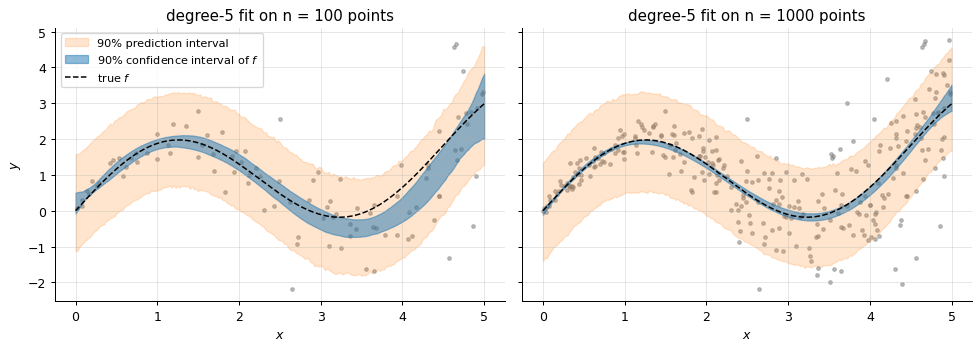

In [3]:
def poly_features(x, degree=5):
    t = (np.asarray(x) - 2.5) / 2.5                  # rescale to [-1, 1]: a well-conditioned fit
    return np.vander(t, degree + 1, increasing=True)

def bootstrap_bands(x, y, xq, B=500, alpha=0.1, seed=0):
    # pairs bootstrap of a least-squares polynomial fit
    # CI: percentiles of the refitted curves f*(x); PI: f*(x) plus a resampled residual
    r = np.random.default_rng(seed)
    Phi, Phiq = poly_features(x), poly_features(xq)
    w = np.linalg.lstsq(Phi, y, rcond=None)[0]
    resid = y - Phi @ w
    fits, preds = np.empty((B, len(xq))), np.empty((B, 20, len(xq)))
    for b in range(B):
        i = r.integers(0, len(x), len(x))
        fits[b] = Phiq @ np.linalg.lstsq(Phi[i], y[i], rcond=None)[0]
        preds[b] = fits[b] + r.choice(resid, (20, len(xq)))           # 20 new observations per refitted curve
    preds = preds.reshape(-1, len(xq))
    lev = [alpha / 2, 1 - alpha / 2]
    return Phiq @ w, np.quantile(fits, lev, axis=0), np.quantile(preds, lev, axis=0)

bands = {n: bootstrap_bands(x_tr[:n], y_tr[:n], xg) for n in (100, 1000)}
i1, i4 = np.searchsorted(xg, 1.0), np.searchsorted(xg, 4.0)
for n, (fit, ci, pi) in bands.items():
    print(f"n = {n:4d}:  CI width {ci[1, i1] - ci[0, i1]:.3f} at x = 1, {ci[1, i4] - ci[0, i4]:.3f} at x = 4   |   "
          f"PI width {pi[1, i1] - pi[0, i1]:.3f} at x = 1, {pi[1, i4] - pi[0, i4]:.3f} at x = 4")
print(f"true 90% PI width 2 x 1.645 sigma(x): {2 * z90 * sigma_true(1.0):.3f} at x = 1, {2 * z90 * sigma_true(4.0):.3f} at x = 4")
ci_w = {n: np.mean(b[1][1] - b[1][0]) for n, b in bands.items()}
print(f"mean CI width: {ci_w[100]:.3f} (n = 100) -> {ci_w[1000]:.3f} (n = 1000), ratio {ci_w[100] / ci_w[1000]:.2f}  (1/sqrt(n) predicts sqrt(10) = 3.16)")
assert ci_w[1000] < ci_w[100]

fit, ci, pi = bands[1000]                                    # does the n = 1000 PI cover 90% of new points?
inside_pi = (y_pool >= np.interp(x_pool, xg, pi[0])) & (y_pool <= np.interp(x_pool, xg, pi[1]))
left = x_pool < 2.5
print(f"coverage of the n = 1000 PI on the pool: {inside_pi.mean():.3f} overall, "
      f"{inside_pi[left].mean():.3f} for x < 2.5, {inside_pi[~left].mean():.3f} for x >= 2.5   (target 0.900)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (n, (fit, ci, pi)) in zip(axes, bands.items()):
    ax.scatter(x_tr[:n][:300], y_tr[:n][:300], s=8, c="gray", alpha=0.5)
    ax.fill_between(xg, pi[0], pi[1], color="tab:orange", alpha=0.2, label="90% prediction interval")
    ax.fill_between(xg, ci[0], ci[1], color="tab:blue", alpha=0.5, label="90% confidence interval of $f$")
    ax.plot(xg, f_true(xg), "k--", lw=1.2, label="true $f$")
    ax.set_title(f"degree-5 fit on n = {n} points"); ax.set_xlabel("$x$")
axes[0].set_ylabel("$y$"); axes[0].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?**
- The confidence band shrinks from a mean width of 0.552 to 0.182 when $n$ grows from 100 to 1,000, a ratio of 3.03, close to the $\sqrt{10} = 3.16$ predicted by $1/\sqrt{n}$. With enough data we know the curve almost exactly.
- The prediction band does not shrink: about 2.76 wide at $n = 1{,}000$, because the noise does not go away. It even has the **same width everywhere**: the bootstrap draws residuals from the whole range of $x$, as if the noise were homoscedastic. The truth is 1.15 wide at $x = 1$ and 3.62 at $x = 4$.
- So its coverage is right on average (0.900) but wrong almost everywhere: 0.989 for $x \lt 2.5$ (too wide) and 0.812 for $x \ge 2.5$ (too narrow). A correct average can hide a wrong interval in every region. Keep this in mind: it is the difference between **marginal** and **conditional** coverage, the subject of section 6.

## 2. Predicting a distribution: a heteroscedastic Gaussian network

Instead of one number, the network outputs a whole Gaussian: a mean $\hat\mu(x)$ and a log-variance $\log\hat\sigma^2(x)$, two heads on a shared trunk. It is trained by maximum likelihood, i.e. by minimising the negative log-likelihood

$$
\ell(x, y) = -\log \mathcal{N}\big(y;\ \hat\mu(x), \hat\sigma^2(x)\big) = \tfrac12\log(2\pi) + \tfrac12\log\hat\sigma^2(x) + \frac{\big(y - \hat\mu(x)\big)^2}{2\,\hat\sigma^2(x)} .
$$

With a constant $\hat\sigma$ this is the MSE, the course's "Gaussian ⇒ MSE". With a free variance, minimise over $v = \hat\sigma^2$ for a fixed residual $r = y - \hat\mu$:

$$
\frac{\partial \ell}{\partial v} = \frac{1}{2v} - \frac{r^2}{2v^2} = 0 \quad\Longrightarrow\quad v = r^2 .
$$

So the variance head learns the **expected squared residual** at $x$, and the residual term is divided by it: noisy points weigh less in the mean, a learned weighted least squares. Two practical details: the head outputs $\log\hat\sigma^2$, so the variance is always positive; and the first 300 steps fit the mean only (MSE), otherwise the network explains its early errors by inflating $\hat\sigma$ and the mean learns slowly.

NLL check: ours 2.03034, nn.GaussianNLLLoss 2.03034


trained in 2.1 s; training NLL 0.971  (the true f and sigma score 0.992 on the same points)
coverage of mu ± 1.645 sigma_hat on the pool: 0.896 overall, 0.903 for x < 2.5, 0.888 for x >= 2.5   (target 0.900)
sigma_hat / sigma on the grid: between 0.83 and 1.19, mean 1.01


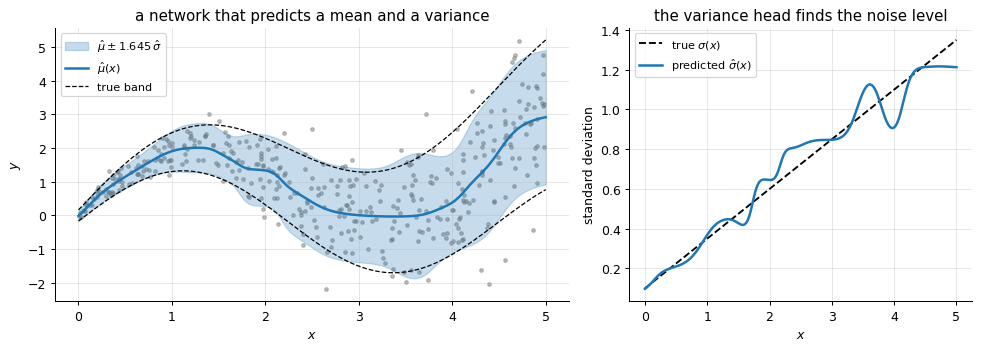

In [4]:
XM, XS = 2.5, 1.45                       # standardise x: mean and sd of U(0, 5)
def to_t(x):
    return torch.tensor((np.asarray(x, dtype=np.float64) - XM) / XS, dtype=torch.float32)[:, None]

class HetNet(nn.Module):
    # shared trunk, two heads: the mean mu(x) and the log-variance log sigma^2(x)
    def __init__(self, hidden=64, p_drop=0.0):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(1, hidden), nn.Tanh(), nn.Dropout(p_drop),
                                  nn.Linear(hidden, hidden), nn.Tanh(), nn.Dropout(p_drop))
        self.mu, self.logvar = nn.Linear(hidden, 1), nn.Linear(hidden, 1)
    def forward(self, x):
        z = self.body(x)
        return self.mu(z).squeeze(-1), self.logvar(z).squeeze(-1)

def gaussian_nll(mu, logvar, y):
    # -log N(y; mu, sigma^2) for each example, written out
    return 0.5 * np.log(2 * np.pi) + 0.5 * logvar + 0.5 * (y - mu) ** 2 / torch.exp(logvar)

def train_het(x, y, seed, steps=2000, lr=5e-3, p_drop=0.0, warmup=300):
    # full-batch Adam: MSE on the mean for `warmup` steps, then the Gaussian NLL
    torch.manual_seed(seed)
    net = HetNet(p_drop=p_drop)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    X, Y = to_t(x), torch.tensor(y, dtype=torch.float32)
    hist = []
    for t in range(steps):
        opt.zero_grad()
        mu, lv = net(X)
        loss = ((Y - mu) ** 2).mean() if t < warmup else gaussian_nll(mu, lv, Y).mean()
        loss.backward(); opt.step()
        hist.append(loss.item())
    return net.eval(), hist

@torch.no_grad()
def predict_het(net, x):
    mu, lv = net(to_t(x))
    return mu.numpy().astype(np.float64), np.exp(0.5 * lv.numpy()).astype(np.float64)

# the hand-written NLL must agree with PyTorch's GaussianNLLLoss (full=True keeps the log(2 pi) constant)
mu_c, lv_c, y_c = torch.randn(50), torch.randn(50), torch.randn(50)
ours, lib = gaussian_nll(mu_c, lv_c, y_c).mean(), nn.GaussianNLLLoss(full=True)(mu_c, y_c, torch.exp(lv_c))
assert torch.allclose(ours, lib, atol=1e-5)
print(f"NLL check: ours {ours.item():.5f}, nn.GaussianNLLLoss {lib.item():.5f}")

t0 = time.time()
het_net, het_hist = train_het(x_tr, y_tr, seed=0)
mu_g, sd_g = predict_het(het_net, xg)
mu_pool, sd_pool = predict_het(het_net, x_pool)
nll_true = np.mean(0.5 * np.log(2 * np.pi) + np.log(sigma_true(x_tr)) + 0.5 * ((y_tr - f_true(x_tr)) / sigma_true(x_tr)) ** 2)
in_gauss = np.abs(y_pool - mu_pool) <= z90 * sd_pool
left = x_pool < 2.5
print(f"trained in {time.time() - t0:.1f} s; training NLL {het_hist[-1]:.3f}  (the true f and sigma score {nll_true:.3f} on the same points)")
print(f"coverage of mu ± 1.645 sigma_hat on the pool: {in_gauss.mean():.3f} overall, {in_gauss[left].mean():.3f} for x < 2.5, "
      f"{in_gauss[~left].mean():.3f} for x >= 2.5   (target 0.900)")
ratio = sd_g / sigma_true(xg)
print(f"sigma_hat / sigma on the grid: between {ratio.min():.2f} and {ratio.max():.2f}, mean {ratio.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
ax.scatter(x_tr[:400], y_tr[:400], s=8, c="gray", alpha=0.5)
ax.fill_between(xg, mu_g - z90 * sd_g, mu_g + z90 * sd_g, color="tab:blue", alpha=0.25, label=r"$\hat\mu \pm 1.645\,\hat\sigma$")
ax.plot(xg, mu_g, "tab:blue", lw=2, label=r"$\hat\mu(x)$")
for s_ in (-1, 1):
    ax.plot(xg, f_true(xg) + s_ * z90 * sigma_true(xg), "k--", lw=1, label="true band" if s_ == 1 else None)
ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title("a network that predicts a mean and a variance"); ax.legend(loc="upper left", fontsize=9)
ax = axes[1]
ax.plot(xg, sigma_true(xg), "k--", label=r"true $\sigma(x)$"); ax.plot(xg, sd_g, "tab:blue", lw=2, label=r"predicted $\hat\sigma(x)$")
ax.set_xlabel("$x$"); ax.set_ylabel("standard deviation"); ax.set_title("the variance head finds the noise level"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?**
- The variance head recovers the noise level without ever being told it: $\hat\sigma(x)/\sigma(x)$ stays between 0.83 and 1.19 on the whole grid. It is wigglier than the mean: it is learned from squared residuals, a much noisier target than $y$. The training NLL, 0.971, is even slightly below the 0.992 of the true model on the same points: the network fits some of the noise of those 1,000 points.
- The interval $\hat\mu \pm 1.645\,\hat\sigma$ covers 0.896 of the pool, and this time the coverage is about right in both halves (0.903 and 0.888). The interval adapts because the model of the noise is right.
- That is the catch: the guarantee is only as good as the assumptions. If the noise were skewed or heavy-tailed, "±1.645 sd" would not hold 90%, and nothing in the method would tell us.

## 3. Quantile regression and the pinball loss

Another way to get an interval: predict two quantiles directly, $\hat q_{0.05}(x)$ and $\hat q_{0.95}(x)$, with no assumption on the shape of the noise. The loss that makes a model predict the $\tau$-quantile is the **pinball loss** of the residual $u = y - q$:

$$
\rho_\tau(u) = \begin{cases} \tau\,u & u \ge 0 \\ (\tau - 1)\,u & u \lt 0 \end{cases} \;=\; \max\big(\tau u,\ (\tau - 1)u\big).
$$

Under-predicting ($u \gt 0$) costs $\tau$ per unit, over-predicting costs $1 - \tau$. With $\tau = 0.9$ under-predicting is 9 times more expensive, so the best constant sits high: at the 90% quantile.

**Proof.** For a constant prediction $q$ and $Y$ with CDF $F$,

$$
\frac{d}{dq}\,\mathbb{E}\big[\rho_\tau(Y - q)\big] = \mathbb{E}\big[-\tau\,\mathbb{1}\{Y \gt q\} + (1 - \tau)\,\mathbb{1}\{Y \lt q\}\big] = -\tau\big(1 - F(q)\big) + (1 - \tau)F(q) = F(q) - \tau .
$$

The derivative increases with $q$ (the risk is convex) and vanishes where $F(q) = \tau$: the minimiser is the $\tau$-quantile. $\blacksquare$ For $\tau = 0.5$, $\rho_{0.5}(u) = |u|/2$: the absolute error, minimised by the median. The same argument with conditional expectations shows that a flexible model trained with $\rho_\tau$ estimates the conditional quantile $q_\tau(x)$. On a sample, $F$ is the empirical CDF and the minimiser is an empirical quantile, which we check first on a skewed sample.

tau = 0.1: argmin of the mean pinball loss = 0.1135,  np.quantile = 0.1135
tau = 0.5: argmin of the mean pinball loss = 0.7226,  np.quantile = 0.7226
tau = 0.9: argmin of the mean pinball loss = 2.3294,  np.quantile = 2.3294
sample mean 1.014: the mean is not the median for a skewed distribution


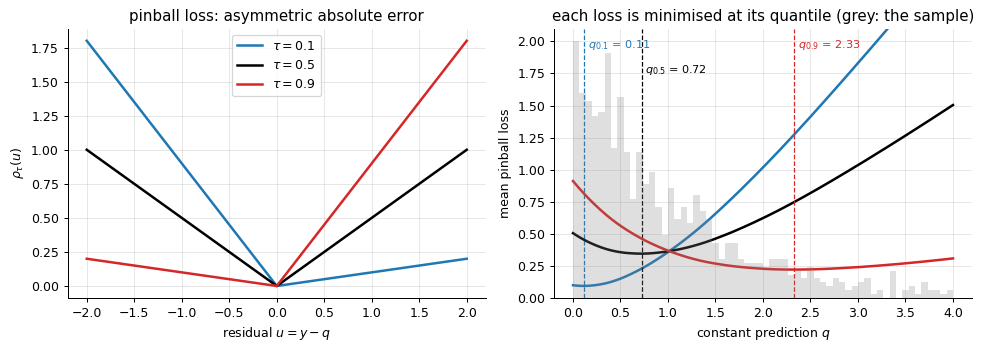

In [5]:
def pinball(u, tau):
    # pinball loss of the residual u = y - q
    return np.maximum(tau * u, (tau - 1) * u)

sample = np.random.default_rng(3).exponential(1.0, 999)        # skewed: mean 1, median log 2 = 0.693
q_star = {}
for tau in (0.1, 0.5, 0.9):
    risk = np.array([pinball(sample - q, tau).mean() for q in sample])   # the minimum is at a data point
    q_star[tau] = sample[np.argmin(risk)]
    q_np = np.quantile(sample, tau, method="inverted_cdf")
    print(f"tau = {tau}: argmin of the mean pinball loss = {q_star[tau]:.4f},  np.quantile = {q_np:.4f}")
    assert q_star[tau] == q_np
print(f"sample mean {sample.mean():.3f}: the mean is not the median for a skewed distribution")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
u = np.linspace(-2, 2, 201)
for tau, c in ((0.1, "tab:blue"), (0.5, "k"), (0.9, "tab:red")):
    axes[0].plot(u, pinball(u, tau), c, lw=2, label=fr"$\tau = {tau}$")
axes[0].set_xlabel(r"residual $u = y - q$"); axes[0].set_ylabel(r"$\rho_\tau(u)$"); axes[0].set_title("pinball loss: asymmetric absolute error"); axes[0].legend()
qs = np.linspace(0, 4, 401)
ax = axes[1]; ax2 = ax.twinx(); ax2.hist(sample, bins=60, range=(0, 4), color="gray", alpha=0.25); ax2.set_yticks([]); ax2.grid(False)
for tau, c in ((0.1, "tab:blue"), (0.5, "k"), (0.9, "tab:red")):
    ax.plot(qs, [pinball(sample - q, tau).mean() for q in qs], c, lw=2)
    ax.axvline(q_star[tau], color=c, ls="--", lw=1)
    ax.text(q_star[tau] + 0.04, {0.1: 1.95, 0.5: 1.75, 0.9: 1.95}[tau], fr"$q_{{{tau}}}$ = {q_star[tau]:.2f}", color=c, fontsize=9)
ax.set_ylim(0, 2.1); ax.set_xlabel("constant prediction $q$"); ax.set_ylabel("mean pinball loss"); ax.set_title("each loss is minimised at its quantile (grey: the sample)")
plt.tight_layout(); plt.show()

The minimiser of the empirical pinball loss is exactly the empirical quantile (the asserts pass): 0.113, 0.723 and 2.329 for $\tau = 0.1, 0.5, 0.9$, against the exact quantiles of the exponential distribution, $-\log(1-\tau) = 0.105, 0.693, 2.303$. Each risk curve is convex, with a kink at every data point.

### 3b. A quantile network and gradient boosting

We train one MLP with three outputs, for $\tau = 0.05, 0.5, 0.95$, on the sum of the three pinball losses (same architecture as section 2), and compare it with scikit-learn's gradient boosting with `loss="quantile"` (one model per $\tau$). The true quantiles are $f(x) \pm 1.645\,\sigma(x)$ and $f(x)$ for the median.

quantile network and 3 boosting models trained in 3.9 s
quantile MLP: coverage of [q_0.05, q_0.95] on the pool 0.881 (target 0.900), mean width 2.336, crossings q_0.05 > q_0.95: 0.000
sklearn GBR : coverage of [q_0.05, q_0.95] on the pool 0.856 (target 0.900), mean width 2.305, crossings q_0.05 > q_0.95: 0.000
quantile MLP on its own training points: coverage 0.900
true band: mean width 2.396


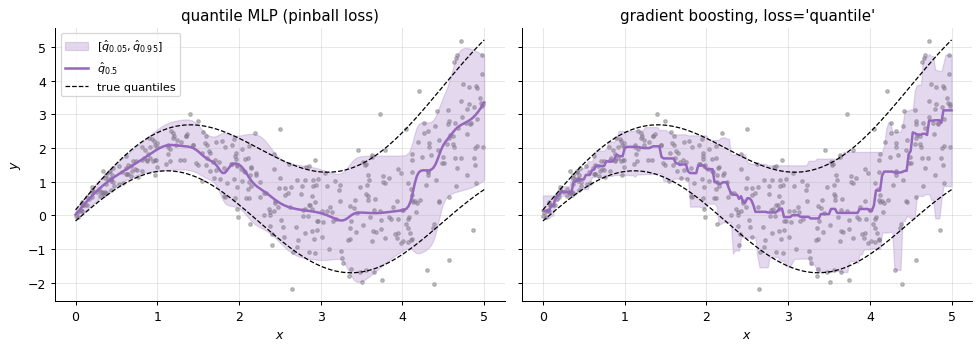

In [6]:
TAUS = torch.tensor([0.05, 0.5, 0.95])

def pinball_t(q, y, taus=TAUS):
    # q: (m, 3) predicted quantiles, y: (m,) targets; mean pinball loss summed over the three levels
    u = y[:, None] - q
    return torch.maximum(taus * u, (taus - 1) * u).mean(0).sum()

def train_quantile_net(x, y, seed=0, steps=3000, lr=5e-3, hidden=64):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(1, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 3))
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    X, Y = to_t(x), torch.tensor(y, dtype=torch.float32)
    for t in range(steps):
        opt.zero_grad(); loss = pinball_t(net(X), Y); loss.backward(); opt.step()
    return net.eval()

@torch.no_grad()
def predict_q(net, x):
    return net(to_t(x)).numpy().astype(np.float64)       # columns: q_0.05, q_0.5, q_0.95

t0 = time.time()
qnet = train_quantile_net(x_tr, y_tr)
Q_g, Q_pool, Q_tr = predict_q(qnet, xg), predict_q(qnet, x_pool), predict_q(qnet, x_tr)
gbr = {a: GradientBoostingRegressor(loss="quantile", alpha=a, n_estimators=200, max_depth=3, learning_rate=0.05,
                                    min_samples_leaf=20, random_state=0).fit(x_tr[:, None], y_tr) for a in (0.05, 0.5, 0.95)}
G_g = np.column_stack([gbr[a].predict(xg[:, None]) for a in (0.05, 0.5, 0.95)])
G_pool = np.column_stack([gbr[a].predict(x_pool[:, None]) for a in (0.05, 0.5, 0.95)])
print(f"quantile network and 3 boosting models trained in {time.time() - t0:.1f} s")
qr_cov = {}
for name, Qp in (("quantile MLP", Q_pool), ("sklearn GBR", G_pool)):
    inside = (y_pool >= Qp[:, 0]) & (y_pool <= Qp[:, 2])
    qr_cov[name] = inside.mean()
    print(f"{name:12s}: coverage of [q_0.05, q_0.95] on the pool {inside.mean():.3f} (target 0.900), "
          f"mean width {np.mean(Qp[:, 2] - Qp[:, 0]):.3f}, crossings q_0.05 > q_0.95: {np.mean(Qp[:, 0] > Qp[:, 2]):.3f}")
qr_train_cov = np.mean((y_tr >= Q_tr[:, 0]) & (y_tr <= Q_tr[:, 2]))
print(f"quantile MLP on its own training points: coverage {qr_train_cov:.3f}")
print(f"true band: mean width {np.mean(2 * z90 * sigma_true(x_pool)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, Qg) in zip(axes, (("quantile MLP (pinball loss)", Q_g), ("gradient boosting, loss='quantile'", G_g))):
    ax.scatter(x_tr[:400], y_tr[:400], s=8, c="gray", alpha=0.5)
    ax.fill_between(xg, Qg[:, 0], Qg[:, 2], color="tab:purple", alpha=0.25, label=r"$[\hat q_{0.05}, \hat q_{0.95}]$")
    ax.plot(xg, Qg[:, 1], "tab:purple", lw=2, label=r"$\hat q_{0.5}$")
    for s_ in (-1, 1):
        ax.plot(xg, f_true(xg) + s_ * z90 * sigma_true(xg), "k--", lw=1, label="true quantiles" if s_ == 1 else None)
    ax.set_title(name); ax.set_xlabel("$x$")
axes[0].set_ylabel("$y$"); axes[0].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.**
- Both models find the widening band without any Gaussian assumption. The network gives smooth quantiles; boosting gives step functions (trees cut $x$ into intervals) and is noisier at the edges.
- Neither reaches 90% on new points: 0.881 for the network and 0.856 for boosting. On its own training points the network covers 0.900. Fitted quantiles are noisy estimates, and every error in a band edge, in either direction, costs coverage on average. Nothing in the method guarantees the level.
- No crossing here, but quantiles fitted separately can cross ($\hat q_{0.05}(x) \gt \hat q_{0.95}(x)$). Common fixes: sort the outputs, or predict the lower quantile plus positive increments (softplus).

## 4. Epistemic uncertainty: deep ensembles and MC dropout

Sections 2 and 3 model the aleatoric noise. They say nothing about how sure the model is of its own curve: far from the data a single network keeps predicting with the same confidence.

**Deep ensemble** (Lakshminarayanan et al., 2017): train $M$ networks from different random initialisations, here $M = 5$ heteroscedastic networks with the recipe of section 2. Each gives $(\hat\mu_m(x), \hat\sigma_m^2(x))$. The ensemble predicts the equal-weight mixture. Its mean is $\bar\mu(x) = \frac1M\sum_m\hat\mu_m(x)$, and by the law of total variance its variance splits in two:

$$
\operatorname{Var}(Y \mid x) \approx \underbrace{\frac1M\sum_{m}\hat\sigma_m^2(x)}_{\text{aleatoric: the noise each member sees}} + \underbrace{\frac1M\sum_{m}\big(\hat\mu_m(x) - \bar\mu(x)\big)^2}_{\text{epistemic: the members disagree}} .
$$

**MC dropout** (Gal and Ghahramani, 2016): train one network with dropout and keep dropout **on** at prediction time. Every forward pass is a different thinned network, and the same decomposition applies to $T = 200$ passes. It costs one training run instead of $M$.

We predict on $x \in [-1.5, 6.5]$, beyond the training range $[0, 5]$.

5 networks + 1 dropout network trained in 14.9 s
     x | true sigma | ensemble: aleatoric sd  epistemic sd | MC dropout: aleatoric sd  epistemic sd
  -1.5 |        -   |            0.080         0.423 |              0.156         0.203
  -0.5 |        -   |            0.055         0.224 |              0.154         0.152
   0.5 |      0.225 |            0.213         0.013 |              0.230         0.095
   2.5 |      0.725 |            0.812         0.014 |              0.842         0.138
   4.5 |      1.225 |            1.179         0.014 |              1.280         0.159
   5.5 |        -   |            1.197         0.070 |              1.299         0.152
   6.5 |        -   |            1.226         0.105 |              1.288         0.147
inside [0, 5]: epistemic sd of the ensemble at most 0.046; outside: up to 0.423


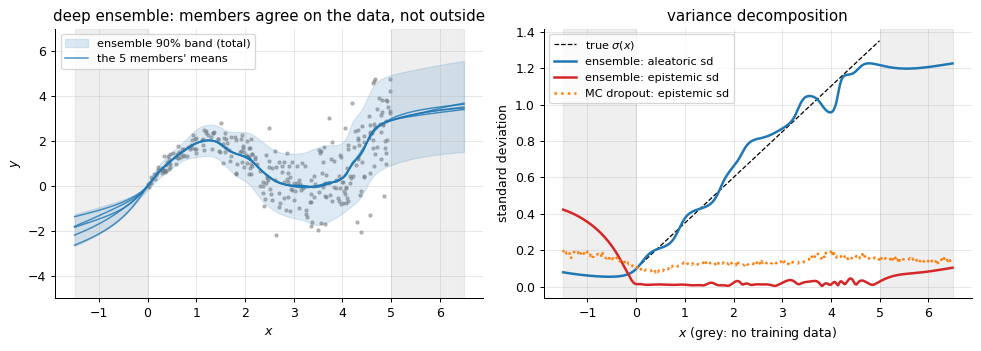

In [7]:
xe = np.linspace(-1.5, 6.5, 321)                       # wider than the data
t0 = time.time()
ensemble = [train_het(x_tr, y_tr, seed=s)[0] for s in range(1, 6)]
preds = [predict_het(m, xe) for m in ensemble]
M_ = np.array([p[0] for p in preds]); V_ = np.array([p[1] ** 2 for p in preds])
mu_ens, ale_ens, epi_ens = M_.mean(0), V_.mean(0), M_.var(0)
mix_var = (V_ + M_ ** 2).mean(0) - mu_ens ** 2          # variance of the equal-weight mixture, from its moments
assert np.allclose(mix_var, ale_ens + epi_ens)            # law of total variance

mcd_net, _ = train_het(x_tr, y_tr, seed=7, p_drop=0.1)
mcd_net.train()                                           # dropout stays ON at prediction time
torch.manual_seed(0)
with torch.no_grad():
    outs = [mcd_net(to_t(xe)) for _ in range(200)]
Mm = np.array([o[0].numpy() for o in outs]); Vm = np.array([np.exp(o[1].numpy()) for o in outs])
ale_mcd, epi_mcd = Vm.mean(0), Mm.var(0)
print(f"5 networks + 1 dropout network trained in {time.time() - t0:.1f} s")
print("     x | true sigma | ensemble: aleatoric sd  epistemic sd | MC dropout: aleatoric sd  epistemic sd")
for x0 in (-1.5, -0.5, 0.5, 2.5, 4.5, 5.5, 6.5):
    i = np.argmin(np.abs(xe - x0)); ts = f"{sigma_true(x0):.3f}" if 0 <= x0 <= 5 else "  -  "
    print(f"{x0:6.1f} |      {ts} |            {np.sqrt(ale_ens[i]):.3f}         {np.sqrt(epi_ens[i]):.3f} |"
          f"              {np.sqrt(ale_mcd[i]):.3f}         {np.sqrt(epi_mcd[i]):.3f}")
ins = (xe >= 0) & (xe <= 5)
print(f"inside [0, 5]: epistemic sd of the ensemble at most {np.sqrt(epi_ens[ins]).max():.3f}; "
      f"outside: up to {np.sqrt(epi_ens[~ins]).max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
for a, b in ((-1.5, 0), (5, 6.5)):
    ax.axvspan(a, b, color="gray", alpha=0.12)
ax.scatter(x_tr[:300], y_tr[:300], s=6, c="gray", alpha=0.5)
tot = np.sqrt(ale_ens + epi_ens)
ax.fill_between(xe, mu_ens - z90 * tot, mu_ens + z90 * tot, color="tab:blue", alpha=0.15, label="ensemble 90% band (total)")
for m in range(5):
    ax.plot(xe, M_[m], lw=1.2, label="the 5 members' means" if m == 0 else None, color="tab:blue", alpha=0.8)
ax.set_ylim(-5, 7); ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title("deep ensemble: members agree on the data, not outside")
ax.legend(loc="upper left", fontsize=9)
ax = axes[1]
for a, b in ((-1.5, 0), (5, 6.5)):
    ax.axvspan(a, b, color="gray", alpha=0.12)
ax.plot(xg, sigma_true(xg), "k--", lw=1, label=r"true $\sigma(x)$")
ax.plot(xe, np.sqrt(ale_ens), "tab:blue", lw=2, label="ensemble: aleatoric sd")
ax.plot(xe, np.sqrt(epi_ens), "tab:red", lw=2, label="ensemble: epistemic sd")
ax.plot(xe, np.sqrt(epi_mcd), "tab:orange", lw=2, ls=":", label="MC dropout: epistemic sd")
ax.set_xlabel("$x$ (grey: no training data)"); ax.set_ylabel("standard deviation"); ax.set_title("variance decomposition"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.**
- Inside the data the five networks agree: their epistemic standard deviation is at most 0.046, tiny next to the aleatoric one (0.1 to 1.35). With 1,000 points the curve is well known; what remains is noise.
- Outside the data the members disagree, and the epistemic part grows: 0.423 at $x = -1.5$, where the sine of $f$ turns and each network extrapolates its own way. At the right edge it grows less (0.105 at $x = 6.5$): tanh networks extrapolate almost linearly there, and agree. Disagreement is a useful alarm, not a measurement.
- MC dropout's epistemic standard deviation changes much less: 0.138 at $x = 2.5$ and 0.203 at $x = -1.5$, while the ensemble's grows thirtyfold. Cheaper, but a weak signal of "I have never seen this". The aleatoric heads are extrapolations too: outside $[0, 5]$ they guess.
- None of these numbers comes with a guarantee. The next section builds intervals that do.

## 5. Split conformal prediction from scratch

Every interval so far relied on the model being right: the Gaussian assumption, well-estimated quantiles, a faithful ensemble. **Conformal prediction** wraps any model and returns intervals whose coverage is guaranteed in finite samples, whatever the model and whatever the distribution of the data. The only assumption is **exchangeability**: the joint distribution of $(X_1, Y_1), \dots, (X_{n+1}, Y_{n+1})$ does not change when we permute them. Independent and identically distributed data are exchangeable.

**Split conformal** for regression at level $1 - \alpha$:

1. Fit a model $\hat\mu$ on $\mathcal{D}_{\text{train}}$ (here the network of section 2; it never sees the calibration data).
2. On a separate calibration set of $n$ points, compute the **nonconformity scores** $s_i = |y_i - \hat\mu(x_i)|$.
3. Let $\hat q$ be the $k$-th smallest score, $k = \lceil (n+1)(1-\alpha) \rceil$, and $\hat q = +\infty$ if $k \gt n$. Equivalently: the empirical quantile of the scores at level $(1-\alpha)(1 + 1/n)$.
4. Predict $C(x) = [\hat\mu(x) - \hat q,\ \hat\mu(x) + \hat q]$.

**Theorem.** If the $n$ calibration points and the test point are exchangeable,

$$
1 - \alpha \;\le\; P\big(Y_{n+1} \in C(X_{n+1})\big) \;\le\; 1 - \alpha + \frac{1}{n+1},
$$

the upper bound holding when the scores have no ties.

**Proof (rank argument).** $Y_{n+1} \in C(X_{n+1})$ exactly when $s_{n+1} \le \hat q = s_{(k)}$, i.e. when $s_{n+1}$ is among the $k$ smallest of the $n+1$ scores. The model was fitted on other data, so the $n+1$ scores are exchangeable too, and the rank of $s_{n+1}$ among them is uniform on $\{1, \dots, n+1\}$ (no ties). Hence

$$
P\big(Y_{n+1} \in C(X_{n+1})\big) = \frac{k}{n+1} = \frac{\lceil (n+1)(1-\alpha) \rceil}{n+1} \in \Big[\,1 - \alpha,\ 1 - \alpha + \frac{1}{n+1}\Big). \qquad \blacksquare
$$

The $+1$ is the test point itself: it is one of $n+1$ exchangeable points. With ties the rank is not exactly uniform, but the lower bound still holds. The probability is over **both** the calibration set and the test point: for one fixed calibration set the coverage is a random number near $1 - \alpha$, and section 5c measures how much it varies.

### 5a. A worked example with 10 calibration points

rank |    x      y   mu(x) | score |y - mu(x)|
   1 | 0.83   1.79   1.70 |  0.092
   2 | 4.47   1.67   1.77 |  0.102
   3 | 4.92   2.59   2.86 |  0.274
   4 | 0.42   0.67   1.00 |  0.334
   5 | 0.68   1.79   1.45 |  0.345
   6 | 4.57   1.84   2.19 |  0.345
   7 | 2.04   0.80   1.30 |  0.501
   8 | 3.61  -1.05  -0.01 |  1.044
   9 | 4.04  -0.90   0.45 |  1.350
  10 | 4.57   0.12   2.17 |  2.055
alpha = 0.10: k = ceil(11 x 0.90) = 10  ->  q_hat = 2.055   guaranteed coverage in [0.900, 0.991]
alpha = 0.20: k = ceil(11 x 0.80) =  9  ->  q_hat = 1.350   guaranteed coverage in [0.800, 0.891]
alpha = 0.30: k = ceil(11 x 0.70) =  8  ->  q_hat = 1.044   guaranteed coverage in [0.700, 0.791]
alpha = 0.05: k = ceil(11 x 0.95) = 11  ->  q_hat = inf   guaranteed coverage in [0.950, 1.000]
new point x = 2.0: mu = 1.332, 90% interval [-0.722, 3.387]


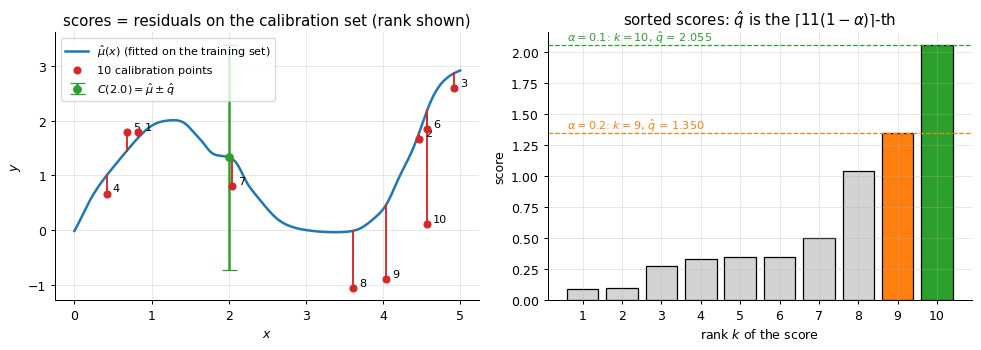

In [8]:
alpha = 0.1

def conformal_quantile(scores, alpha):
    # the k-th smallest score, k = ceil((n + 1)(1 - alpha)); +inf if k > n
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha) - 1e-9))     # the tiny shift protects against rounding, e.g. 11 * 0.9
    return np.inf if k > n else np.sort(scores)[k - 1]

x10, y10, mu10 = x_pool[:10], y_pool[:10], mu_pool[:10]
s10 = np.abs(y10 - mu10)
print("rank |    x      y   mu(x) | score |y - mu(x)|")
for r_, i in enumerate(np.argsort(s10), 1):
    print(f"{r_:4d} | {x10[i]:4.2f}  {y10[i]:5.2f}  {mu10[i]:5.2f} |  {s10[i]:.3f}")
for a in (0.1, 0.2, 0.3, 0.05):
    k = int(np.ceil(11 * (1 - a) - 1e-9))
    q = conformal_quantile(s10, a)
    if np.isfinite(q):
        assert q == np.quantile(s10, (1 - a) * (1 + 1 / 10), method="higher")
    print(f"alpha = {a:.2f}: k = ceil(11 x {1 - a:.2f}) = {k:2d}  ->  q_hat = {q:.3f}   guaranteed coverage in [{1 - a:.3f}, {min(1, 1 - a + 1 / 11):.3f}]")
x_new = 2.0
mu_new = predict_het(het_net, [x_new])[0][0]
q10 = conformal_quantile(s10, alpha)
print(f"new point x = {x_new}: mu = {mu_new:.3f}, 90% interval [{mu_new - q10:.3f}, {mu_new + q10:.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(xg, mu_g, "tab:blue", lw=2, label=r"$\hat\mu(x)$ (fitted on the training set)")
order = np.argsort(s10)
for r_, i in enumerate(order, 1):
    ax.plot([x10[i], x10[i]], [mu10[i], y10[i]], "tab:red", lw=1.5)
    ax.annotate(str(r_), (x10[i], y10[i]), textcoords="offset points", xytext=(5, 2), fontsize=9)
ax.scatter(x10, y10, c="tab:red", s=30, zorder=3, label="10 calibration points")
ax.errorbar([x_new], [mu_new], yerr=[[q10], [q10]], fmt="o", color="tab:green", capsize=6, lw=2, label=r"$C(2.0) = \hat\mu \pm \hat q$")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title("scores = residuals on the calibration set (rank shown)"); ax.legend(fontsize=9, loc="upper left")
ax = axes[1]
srt = np.sort(s10)
cols = ["lightgray"] * 10; cols[9] = "tab:green"; cols[8] = "tab:orange"
ax.bar(np.arange(1, 11), srt, color=cols, edgecolor="k")
ax.axhline(srt[9], color="tab:green", ls="--", lw=1); ax.axhline(srt[8], color="tab:orange", ls="--", lw=1)
ax.text(0.6, srt[9] + 0.03, r"$\alpha = 0.1$: $k = 10$, $\hat q$ = %.3f" % srt[9], color="tab:green", fontsize=9)
ax.text(0.6, srt[8] + 0.03, r"$\alpha = 0.2$: $k = 9$, $\hat q$ = %.3f" % srt[8], color="tab:orange", fontsize=9)
ax.set_xticks(range(1, 11)); ax.set_xlabel("rank $k$ of the score"); ax.set_ylabel("score"); ax.set_title(r"sorted scores: $\hat q$ is the $\lceil 11(1-\alpha)\rceil$-th")
plt.tight_layout(); plt.show()

**What just happened?**
- With $n = 10$ and $\alpha = 0.1$, $k = \lceil 11 \times 0.9 \rceil = \lceil 9.9 \rceil = 10$: $\hat q$ is the **largest** score, 2.055. The 90% interval at $x = 2$ is $\hat\mu(2) \pm$ 2.055 $=$ [-0.722, 3.387].
- The guarantee for this procedure is $P(Y \in C) = 10/11 = 0.909$: the new point's score is equally likely to take any of the 11 ranks, and it is covered unless it is the largest of the 11.
- $\alpha = 0.2$ gives $k = 9$ (the second largest score, 1.350) and $\alpha = 0.3$ gives $k = 8$. For $\alpha = 0.05$, $k = \lceil 10.45 \rceil = 11 \gt 10$: with 10 calibration points no finite interval can promise 95%. In general a finite $\hat q$ needs $n \ge 1/\alpha - 1$, i.e. 19 points for 95% and 99 for 99%.
- The plain empirical 90% quantile of 10 scores would be the 9th, which gives only $9/11 = 0.818$. The $(n+1)$ correction is not a detail for small $n$.

### 5b. All 1,000 calibration points

n = 1000: k = ceil(1001 x 0.9) = 901, q_hat = 1.397, interval mu(x) ± 1.397 (width 2.793)
coverage on the 19000 other pool points: 0.9011
guarantee, on average over calibration sets: between 0.9000 and 0.9010; exact value k/(n+1) = 0.9001
for comparison: 90% quantile of |noise| over the pool 1.386


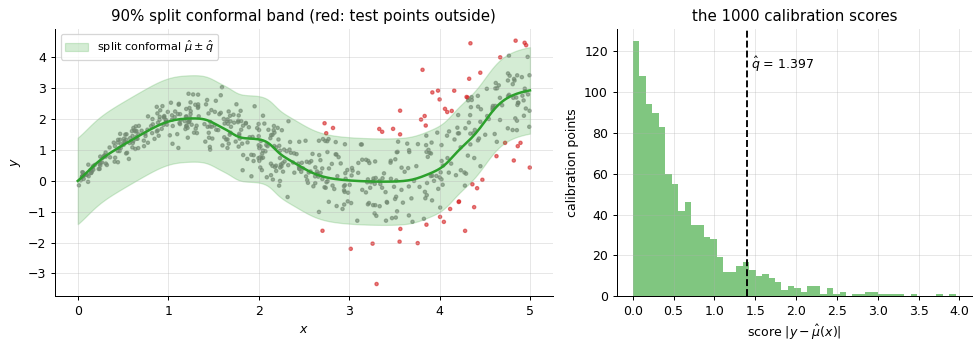

In [9]:
n_cal = 1000
s_pool = np.abs(y_pool - mu_pool)                      # score of every pool point
s_cal, s_test = s_pool[:n_cal], s_pool[n_cal:]
x_test, y_test, mu_test, sd_test = x_pool[n_cal:], y_pool[n_cal:], mu_pool[n_cal:], sd_pool[n_cal:]
k_cal = int(np.ceil((n_cal + 1) * (1 - alpha) - 1e-9))
q_abs = conformal_quantile(s_cal, alpha)
in_abs = s_test <= q_abs
print(f"n = {n_cal}: k = ceil({n_cal + 1} x 0.9) = {k_cal}, q_hat = {q_abs:.3f}, interval mu(x) ± {q_abs:.3f} (width {2 * q_abs:.3f})")
print(f"coverage on the {len(s_test)} other pool points: {in_abs.mean():.4f}")
print(f"guarantee, on average over calibration sets: between {1 - alpha:.4f} and {1 - alpha + 1 / (n_cal + 1):.4f}; exact value k/(n+1) = {k_cal / (n_cal + 1):.4f}")
print(f"for comparison: 90% quantile of |noise| over the pool {np.quantile(np.abs(y_pool - f_true(x_pool)), 0.9):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
ax.scatter(x_test[:600], y_test[:600], s=7, c=np.where(in_abs[:600], "gray", "tab:red"), alpha=0.6)
ax.fill_between(xg, mu_g - q_abs, mu_g + q_abs, color="tab:green", alpha=0.2, label=r"split conformal $\hat\mu \pm \hat q$")
ax.plot(xg, mu_g, "tab:green", lw=2)
ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title("90% split conformal band (red: test points outside)"); ax.legend(loc="upper left", fontsize=9)
ax = axes[1]
ax.hist(s_cal, bins=50, color="tab:green", alpha=0.6)
ax.axvline(q_abs, color="k", ls="--"); ax.text(q_abs + 0.05, ax.get_ylim()[1] * 0.85, r"$\hat q$ = %.3f" % q_abs, fontsize=10)
ax.set_xlabel(r"score $|y - \hat\mu(x)|$"); ax.set_ylabel("calibration points"); ax.set_title(f"the {n_cal} calibration scores")
plt.tight_layout(); plt.show()

**Interpretation.** With 1,000 calibration points $k = 901$ and $\hat q =$ 1.397: the band $\hat\mu(x) \pm$ 1.397 covers 0.901 of the 19,000 other pool points. No assumption about the network or the noise was used; only that the calibration and test points come from the same distribution. Note where the misses are, in red: almost all at large $x$. The band has the same width everywhere, like the bootstrap PI of section 1b. We come back to it in section 6.

### 5c. Coverage over 1,000 random splits

For one calibration set, the coverage on new points is $c = F_S(\hat q)$, where $F_S$ is the CDF of the score. The values $F_S(s_i)$ are i.i.d. uniform on $(0, 1)$ and $\hat q = s_{(k)}$, so $c$ is the $k$-th smallest of $n$ uniforms:

$$
c \sim \mathrm{Beta}(k,\ n + 1 - k), \qquad \mathbb{E}[c] = \frac{k}{n+1}, \qquad \operatorname{sd}(c) = \sqrt{\frac{\mathbb{E}[c]\,\big(1 - \mathbb{E}[c]\big)}{n+2}} \approx \sqrt{\frac{\alpha(1-\alpha)}{n}} .
$$

We redraw the calibration set 1,000 times from the pool, for $n$ = 20, 50, 200 and 1,000, each time measuring the coverage on 5,000 other pool points. The finite test set adds a little binomial noise, of variance about $0.09/5000$.

n =   20: k =  19 | mean coverage 0.9066, theory k/(n+1) = 0.9048 | sd 0.0628, Beta sd 0.0626 (+ test noise: 0.0627) | below 0.85: 0.166 | mean width 3.117
n =   50: k =  46 | mean coverage 0.9018, theory k/(n+1) = 0.9020 | sd 0.0414, Beta sd 0.0412 (+ test noise: 0.0415) | below 0.85: 0.114 | mean width 2.904


n =  200: k = 181 | mean coverage 0.9000, theory k/(n+1) = 0.9005 | sd 0.0215, Beta sd 0.0211 (+ test noise: 0.0215) | below 0.85: 0.021 | mean width 2.811
n = 1000: k = 901 | mean coverage 0.9001, theory k/(n+1) = 0.9001 | sd 0.0103, Beta sd 0.0095 (+ test noise: 0.0104) | below 0.85: 0.000 | mean width 2.792
(0.7 s)
n = 200: mean coverage 0.9000 lies in [1 - alpha, 1 - alpha + 1/(n+1)] = [0.9000, 0.9050] (up to Monte Carlo error, 3 se = 0.0020)


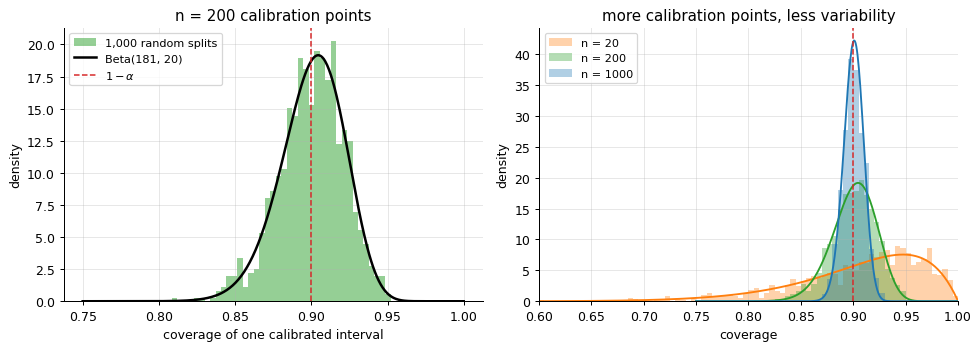

In [10]:
def coverage_over_splits(scores, n, alpha=0.1, n_splits=1000, n_test=5000, seed=0):
    r = np.random.default_rng(seed)
    cov, qs = np.empty(n_splits), np.empty(n_splits)
    for j in range(n_splits):
        perm = r.permutation(len(scores))
        qs[j] = conformal_quantile(scores[perm[:n]], alpha)
        cov[j] = np.mean(scores[perm[n:n + n_test]] <= qs[j])
    return cov, qs

t0 = time.time()
splits = {}
for n in (20, 50, 200, 1000):
    cov, qs = coverage_over_splits(s_pool, n)
    k = int(np.ceil((n + 1) * (1 - alpha) - 1e-9)); beta = stats.beta(k, n + 1 - k)
    sd_tot = np.sqrt(beta.var() + beta.mean() * (1 - beta.mean()) / 5000)
    splits[n] = dict(cov=cov, qs=qs, k=k, beta=beta)
    print(f"n = {n:4d}: k = {k:3d} | mean coverage {cov.mean():.4f}, theory k/(n+1) = {k / (n + 1):.4f} | "
          f"sd {cov.std():.4f}, Beta sd {beta.std():.4f} (+ test noise: {sd_tot:.4f}) | below 0.85: {np.mean(cov < 0.85):.3f} | mean width {2 * qs.mean():.3f}")
print(f"({time.time() - t0:.1f} s)")
cov200 = splits[200]["cov"]; se = cov200.std() / np.sqrt(len(cov200))
assert 1 - alpha - 3 * se <= cov200.mean() <= 1 - alpha + 1 / 201 + 3 * se
print(f"n = 200: mean coverage {cov200.mean():.4f} lies in [1 - alpha, 1 - alpha + 1/(n+1)] = [0.9000, {1 - alpha + 1 / 201:.4f}] "
      f"(up to Monte Carlo error, 3 se = {3 * se:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]; cgrid = np.linspace(0.75, 1.0, 400)
ax.hist(cov200, bins=40, density=True, color="tab:green", alpha=0.5, label="1,000 random splits")
ax.plot(cgrid, splits[200]["beta"].pdf(cgrid), "k", lw=2, label=f"Beta({splits[200]['k']}, {201 - splits[200]['k']})")
ax.axvline(0.9, color="tab:red", ls="--", lw=1.2, label=r"$1 - \alpha$")
ax.set_xlabel("coverage of one calibrated interval"); ax.set_ylabel("density"); ax.set_title("n = 200 calibration points"); ax.legend(fontsize=9)
ax = axes[1]
for n, c in ((20, "tab:orange"), (200, "tab:green"), (1000, "tab:blue")):
    ax.hist(splits[n]["cov"], bins=np.linspace(0.6, 1.0, 81), density=True, color=c, alpha=0.35, label=f"n = {n}")
    ax.plot(cgrid if n > 20 else np.linspace(0.6, 1, 400), splits[n]["beta"].pdf(cgrid if n > 20 else np.linspace(0.6, 1, 400)), color=c, lw=1.5)
ax.axvline(0.9, color="tab:red", ls="--", lw=1.2)
ax.set_xlim(0.6, 1.0); ax.set_xlabel("coverage"); ax.set_ylabel("density"); ax.set_title("more calibration points, less variability"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.**
- The average coverage matches $k/(n+1)$ for every $n$ (e.g. 0.9000 for $n = 200$, theory 0.9005), and the histograms follow the Beta densities. The guarantee is exactly what the theory says, no more and no less.
- But one calibration set is one draw. With $n = 20$ the coverage of the interval you actually deploy has a standard deviation of 0.063: 16.6% of the splits cover less than 85%. With $n = 1{,}000$ the standard deviation is 0.0103 (the Beta part alone is 0.0095; the rest is the noise of the finite test set).
- Rule of thumb: $\operatorname{sd} \approx \sqrt{\alpha(1-\alpha)/n}$, so a few hundred to a thousand calibration points give coverage within about ±2 points of the target. Small $n$ also makes the interval wider on average and more variable (mean width 3.12 for $n = 20$ against 2.79 for $n = 1{,}000$).

## 6. Conditional coverage: normalised scores and CQR

The guarantee is **marginal**: on average over $X$. What we would like is **conditional** coverage, $P(Y \in C(X) \mid X = x) \ge 1 - \alpha$ for every $x$. It cannot be guaranteed in general with finite samples and no assumptions (Vovk, 2012; Barber et al., 2021), but the choice of score decides how close we get. The constant-width interval $\hat\mu(x) \pm \hat q$ cannot adapt to heteroscedastic noise: it must be too wide where the noise is small and too narrow where it is large.

Two adaptive scores. Both have exactly the same guarantee, because the proof of section 5 only used the exchangeability of the scores, never their form:

- **Normalised (locally weighted) score**: $s = |y - \hat\mu(x)|\,/\,\hat\sigma(x)$, with the predicted spread of section 2. Inverting $s \le \hat q$ gives $C(x) = \hat\mu(x) \pm \hat q\,\hat\sigma(x)$: wider where the model expects noise. If $\hat\sigma$ is right and the noise Gaussian, $\hat q \approx 1.645$.
- **Conformalised quantile regression** (CQR, Romano, Patterson and Candès, 2019): start from the quantile band of section 3 and score how far $y$ falls outside it, $s = \max\big(\hat q_{\alpha/2}(x) - y,\ y - \hat q_{1-\alpha/2}(x)\big)$, negative inside the band. Then $C(x) = [\hat q_{\alpha/2}(x) - \hat q,\ \hat q_{1-\alpha/2}(x) + \hat q]$: conformal moves both band edges by one constant, which is negative if the raw band over-covers.

We cut $[0, 5]$ into 10 bins and measure the test coverage in each.

q_hat: constant 1.397, normalised 1.731 (Gaussian value 1.645), CQR +0.062
method             | coverage | mean width | coverage per bin of x (0-0.5, ..., 4.5-5)
constant |y - mu|  |   0.901  |    2.793   | [1.   1.   1.   0.99 0.96 0.92 0.86 0.81 0.77 0.71]
normalised         |   0.913  |    2.530   | [0.92 0.89 0.93 0.91 0.94 0.94 0.9  0.9  0.9  0.9 ]
CQR                |   0.907  |    2.460   | [0.94 0.92 0.94 0.91 0.95 0.92 0.89 0.88 0.86 0.87]
raw quantile band  |   0.882  |    2.337   | [0.87 0.87 0.91 0.88 0.94 0.9  0.87 0.87 0.84 0.86]


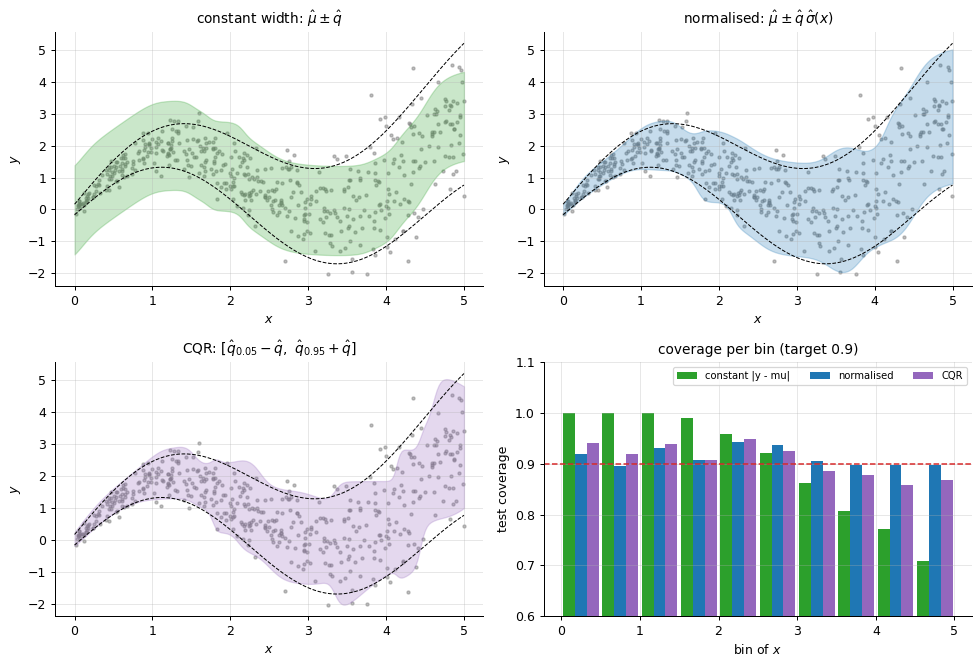

In [11]:
bins = np.linspace(0, 5, 11)
def by_bin(x, inside):
    b = np.clip(np.digitize(x, bins) - 1, 0, 9)
    return np.array([inside[b == j].mean() for j in range(10)])

s_norm = np.abs(y_pool - mu_pool) / sd_pool                         # normalised score
q_norm = conformal_quantile(s_norm[:n_cal], alpha)
in_norm = s_norm[n_cal:] <= q_norm
lo_pool, hi_pool = Q_pool[:, 0], Q_pool[:, 2]
s_cqr = np.maximum(lo_pool - y_pool, y_pool - hi_pool)              # CQR score
q_cqr = conformal_quantile(s_cqr[:n_cal], alpha)
in_cqr = s_cqr[n_cal:] <= q_cqr
in_raw = (y_test >= lo_pool[n_cal:]) & (y_test <= hi_pool[n_cal:])  # quantile band without conformal

methods = {"constant |y - mu|": (in_abs, np.full(len(x_test), 2 * q_abs)),
           "normalised": (in_norm, 2 * q_norm * sd_test),
           "CQR": (in_cqr, hi_pool[n_cal:] - lo_pool[n_cal:] + 2 * q_cqr),
           "raw quantile band": (in_raw, hi_pool[n_cal:] - lo_pool[n_cal:])}
print(f"q_hat: constant {q_abs:.3f}, normalised {q_norm:.3f} (Gaussian value 1.645), CQR {q_cqr:+.3f}")
print("method             | coverage | mean width | coverage per bin of x (0-0.5, ..., 4.5-5)")
cov_bins = {}
for name, (inside, width) in methods.items():
    cov_bins[name] = by_bin(x_test, inside)
    print(f"{name:18s} |   {inside.mean():.3f}  |    {width.mean():.3f}   | {np.round(cov_bins[name], 2)}")
for name in ("constant |y - mu|", "normalised", "CQR"):
    assert abs(methods[name][0].mean() - 0.9) < 0.03                # marginal guarantee (one calibration set)
assert cov_bins["normalised"].min() > cov_bins["constant |y - mu|"].min() + 0.1

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
bands_plot = (("constant width: $\\hat\\mu \\pm \\hat q$", mu_g - q_abs, mu_g + q_abs, "tab:green"),
              ("normalised: $\\hat\\mu \\pm \\hat q\\,\\hat\\sigma(x)$", mu_g - q_norm * sd_g, mu_g + q_norm * sd_g, "tab:blue"),
              ("CQR: $[\\hat q_{0.05} - \\hat q,\\ \\hat q_{0.95} + \\hat q]$", Q_g[:, 0] - q_cqr, Q_g[:, 2] + q_cqr, "tab:purple"))
for ax, (title, lo, hi, c) in zip(axes.flat[:3], bands_plot):
    ax.scatter(x_test[:500], y_test[:500], s=6, c="gray", alpha=0.5)
    ax.fill_between(xg, lo, hi, color=c, alpha=0.25)
    for s_ in (-1, 1):
        ax.plot(xg, f_true(xg) + s_ * z90 * sigma_true(xg), "k--", lw=0.8)
    ax.set_title(title, fontsize=11); ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax = axes[1, 1]; centers = (bins[:-1] + bins[1:]) / 2
for j, (name, c) in enumerate((("constant |y - mu|", "tab:green"), ("normalised", "tab:blue"), ("CQR", "tab:purple"))):
    ax.bar(centers + (j - 1) * 0.15, cov_bins[name], width=0.15, color=c, label=name)
ax.axhline(0.9, color="tab:red", ls="--", lw=1.2)
ax.set_ylim(0.6, 1.1); ax.set_xlabel("bin of $x$"); ax.set_ylabel("test coverage"); ax.set_title("coverage per bin (target 0.9)", fontsize=11); ax.legend(fontsize=8, loc="upper right", ncol=3)
plt.tight_layout(); plt.show()

**What just happened?**
- All three methods cover about 90% overall (0.901, 0.913, 0.907): that part is guaranteed. Bin by bin the stories differ.
- The **constant** band over-covers small $x$ (1.00 in the first bin) and under-covers large $x$ (0.71 in the last): a 90% average made of 100% and 70%.
- The **normalised** score has $\hat q =$ 1.731, close to the Gaussian 1.645 because $\hat\sigma$ is good, and its coverage stays between 0.89 and 0.94 in every bin. Its mean width is also smaller, 2.530 against 2.793: adaptive intervals are not only fairer, they are more informative.
- **CQR** adds only $\hat q =$ +0.062 to the raw quantile band, because the band already covered 0.882; its worst bin is 0.86. Conformal fixed the marginal level, but conditional coverage is only as good as the quantile estimates, which are a little too narrow at large $x$ (section 3b).

## 7. A real dataset: California housing

20,640 districts from the 1990 US census, 8 features (median income, house age, average rooms, location, …), and as target the median house value in units of 100,000 dollars, capped at 5.0. We use 10,000 districts to train, 5,000 to calibrate and 5,640 to test. A histogram gradient-boosting model predicts the mean; two more, with the quantile loss at $\tau = 0.05$ and $0.95$, give the band for CQR. We compare the coverage and the width in the five quintiles of median income.

20640 districts, 8 features; models trained in 2.1 s; test R^2 of the mean model 0.836
q_hat: split conformal 0.704, CQR +0.107
method            | coverage | mean width | coverage by income quintile | mean width by quintile
split conformal   |   0.905  |   1.407    | [0.939 0.937 0.892 0.897 0.858] | [1.41 1.41 1.41 1.41 1.41]
CQR               |   0.911  |   1.367    | [0.927 0.903 0.903 0.918 0.902] | [1.09 1.2  1.36 1.51 1.67]
raw quantile band |   0.784  |   1.152    | [0.782 0.791 0.795 0.839 0.711] | [0.87 0.99 1.15 1.29 1.46]


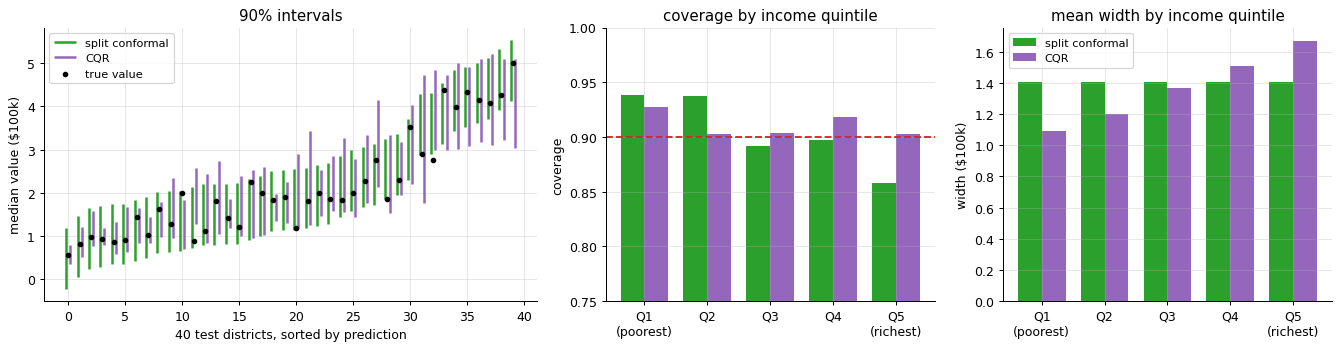

In [12]:
t0 = time.time()
house = fetch_california_housing(data_home="data/sklearn")
Xh, yh = house.data, house.target
perm = np.random.default_rng(7).permutation(len(yh))
itr, ica, ite = perm[:10000], perm[10000:15000], perm[15000:]
hgb = dict(max_iter=300, learning_rate=0.1, max_leaf_nodes=31, early_stopping=False, random_state=0)
m_mean = HistGradientBoostingRegressor(**hgb).fit(Xh[itr], yh[itr])
m_lo = HistGradientBoostingRegressor(loss="quantile", quantile=0.05, **hgb).fit(Xh[itr], yh[itr])
m_hi = HistGradientBoostingRegressor(loss="quantile", quantile=0.95, **hgb).fit(Xh[itr], yh[itr])
mu_c, lo_c, hi_c = [m.predict(Xh[ica]) for m in (m_mean, m_lo, m_hi)]     # calibration districts
mu_t, lo_t, hi_t = [m.predict(Xh[ite]) for m in (m_mean, m_lo, m_hi)]     # test districts
yc, yt = yh[ica], yh[ite]
print(f"{len(yh)} districts, {Xh.shape[1]} features; models trained in {time.time() - t0:.1f} s; "
      f"test R^2 of the mean model {1 - np.mean((yt - mu_t) ** 2) / np.var(yt):.3f}")

qh_abs = conformal_quantile(np.abs(yc - mu_c), alpha)
qh_cqr = conformal_quantile(np.maximum(lo_c - yc, yc - hi_c), alpha)
house_res = {"split conformal": ((np.abs(yt - mu_t) <= qh_abs), np.full(len(yt), 2 * qh_abs), mu_t - qh_abs, mu_t + qh_abs),
             "CQR": (((yt >= lo_t - qh_cqr) & (yt <= hi_t + qh_cqr)), hi_t - lo_t + 2 * qh_cqr, lo_t - qh_cqr, hi_t + qh_cqr),
             "raw quantile band": (((yt >= lo_t) & (yt <= hi_t)), hi_t - lo_t, lo_t, hi_t)}
print(f"q_hat: split conformal {qh_abs:.3f}, CQR {qh_cqr:+.3f}")
grp = np.digitize(Xh[ite, 0], np.quantile(Xh[ite, 0], [0.2, 0.4, 0.6, 0.8]))     # quintiles of median income
print("method            | coverage | mean width | coverage by income quintile | mean width by quintile")
house_grp = {}
for name, (inside, width, lo, hi) in house_res.items():
    cg = np.array([inside[grp == g].mean() for g in range(5)]); wg = np.array([width[grp == g].mean() for g in range(5)])
    house_grp[name] = (cg, wg)
    print(f"{name:17s} |   {inside.mean():.3f}  |   {width.mean():.3f}    | {np.round(cg, 3)} | {np.round(wg, 2)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1.5, 1, 1]})
ax = axes[0]; pick = np.random.default_rng(1).choice(len(yt), 40, replace=False); pick = pick[np.argsort(mu_t[pick])]
for j, (name, c, dx) in enumerate((("split conformal", "tab:green", -0.18), ("CQR", "tab:purple", 0.18))):
    _, _, lo, hi = house_res[name]
    ax.vlines(np.arange(40) + dx, lo[pick], hi[pick], color=c, lw=2, label=name)
ax.scatter(np.arange(40), yt[pick], c="k", s=12, zorder=3, label="true value")
ax.set_xlabel("40 test districts, sorted by prediction"); ax.set_ylabel("median value ($100k)"); ax.set_title("90% intervals"); ax.legend(fontsize=9, loc="upper left")
for ax, j, title in ((axes[1], 0, "coverage by income quintile"), (axes[2], 1, "mean width by income quintile")):
    for i, (name, c) in enumerate((("split conformal", "tab:green"), ("CQR", "tab:purple"))):
        ax.bar(np.arange(5) + (i - 0.5) * 0.38, house_grp[name][j], width=0.38, color=c, label=name)
    ax.set_xticks(range(5)); ax.set_xticklabels(["Q1\n(poorest)", "Q2", "Q3", "Q4", "Q5\n(richest)"]); ax.set_title(title)
axes[1].axhline(0.9, color="tab:red", ls="--"); axes[1].set_ylim(0.75, 1.0); axes[1].set_ylabel("coverage")
axes[2].set_ylabel("width ($100k)"); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.**
- Both conformal methods hit the target overall: 0.905 for split conformal and 0.911 for CQR. The raw quantile band covers only 0.784: on real data, uncorrected quantile models miss the level too.
- Split conformal is a band of $\pm$0.704 (±70,364 dollars) for every district: too wide for the cheap, predictable ones and too narrow for the expensive ones. Its coverage ranges from 0.939 in the poorest quintile down to 0.858 in the richest.
- CQR is **narrower on average** (1.367 against 1.407) and fairer across groups (coverage between 0.902 and 0.927): it spends width where the uncertainty is. Same guarantee, better intervals: the score is where the modelling effort goes.

## 8. Classification: calibration, temperature scaling and prediction sets

A classifier already outputs probabilities $\hat p_k(x)$. Two questions: are they **calibrated** (of the images predicted with confidence 0.8, are 80% right?), and how do we turn them into a **set** of classes with a guaranteed coverage?

We train an MLP 784–256–128–10 on Fashion-MNIST (28×28 grey images of 10 kinds of clothing) for 30 epochs with no regularisation, long enough to overfit a little: networks trained this way tend to be **over-confident** (Guo et al., 2017). 55,000 images train it; 5,000 validation images fit the temperature; the 10,000 test images are split into 5,000 for conformal calibration and 5,000 for testing.

In [13]:
t0 = time.time()
fm_tr = torchvision.datasets.FashionMNIST("data", train=True, download=True)
fm_te = torchvision.datasets.FashionMNIST("data", train=False, download=True)
CLASSES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]
Xa = fm_tr.data.float().div(255).reshape(-1, 784); ya = fm_tr.targets
Xb = fm_te.data.float().div(255).reshape(-1, 784); yb = fm_te.targets
p_ = torch.randperm(60000, generator=torch.Generator().manual_seed(0))
Xv, yv, Xt, yt_ = Xa[p_[:5000]], ya[p_[:5000]], Xa[p_[5000:]], ya[p_[5000:]]

torch.manual_seed(0)
clf = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
for epoch in range(30):
    perm = torch.randperm(len(Xt))
    for i in range(0, len(Xt), 256):
        b = perm[i:i + 256]
        opt.zero_grad(); F.cross_entropy(clf(Xt[b].to(device)), yt_[b].to(device)).backward(); opt.step()
clf.eval()
with torch.no_grad():
    Lv, Lb = clf(Xv.to(device)).cpu().double(), clf(Xb.to(device)).cpu().double()
print(f"trained in {time.time() - t0:.1f} s")
print(f"validation: accuracy {(Lv.argmax(1) == yv).double().mean():.4f}, NLL {F.cross_entropy(Lv, yv):.4f}")
print(f"test:       accuracy {(Lb.argmax(1) == yb).double().mean():.4f}, NLL {F.cross_entropy(Lb, yb):.4f}")

trained in 12.5 s
validation: accuracy 0.8902, NLL 0.3490
test:       accuracy 0.8901, NLL 0.3523


### 8a. Reliability diagram, ECE and temperature scaling

Group the test images by their top-label confidence $\hat p_{\max}(x)$ into 15 bins $B_b$ of width 1/15. A calibrated model has accuracy ≈ confidence in every bin. The **expected calibration error** is the weighted average gap,

$$
\mathrm{ECE} = \sum_{b} \frac{|B_b|}{N}\,\big|\operatorname{acc}(B_b) - \operatorname{conf}(B_b)\big| .
$$

**Temperature scaling** divides all logits $\mathbf{z}$ by one scalar $T \gt 0$ before the softmax, $\hat{\mathbf p} = \operatorname{softmax}(\mathbf{z}/T)$, with $T$ chosen to minimise the NLL on the validation set. $T \gt 1$ flattens over-confident probabilities. Dividing by $T$ keeps the order of the logits, so the predicted class and the accuracy do not change; only the confidence moves. One parameter, fitted in a second, and it is often the best post-hoc calibration method for neural networks.

temperature: grid search 1.596, scipy minimize_scalar 1.594
validation NLL: 0.3490 at T = 1 -> 0.3106 at T = 1.59
test NLL:       0.3523 -> 0.3153
test ECE:       0.0368 -> 0.0155   (accuracy unchanged: 0.8901)
mean confidence 0.9266 -> 0.8813


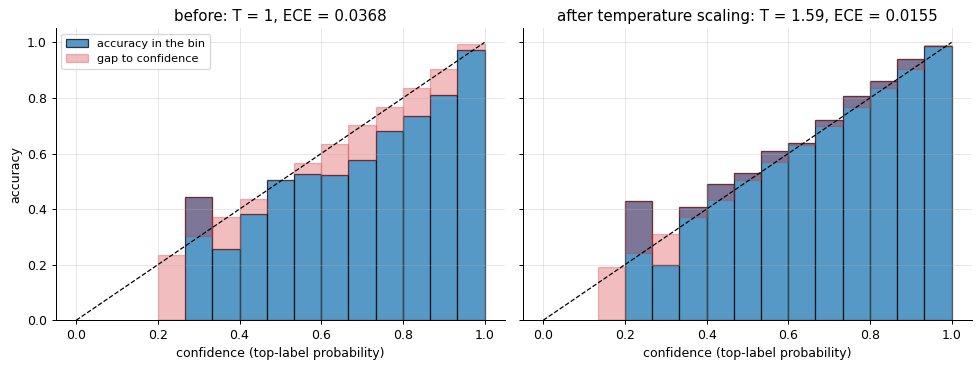

In [14]:
def reliability(P, y, n_bins=15):
    # per-bin confidence, accuracy and count of the top-label prediction, and the ECE
    conf, pred = P.max(1), P.argmax(1)
    acc = (pred == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    b = np.clip(np.digitize(conf, edges[1:-1], right=True), 0, n_bins - 1)
    cnt = np.bincount(b, minlength=n_bins)
    cb = np.bincount(b, conf, n_bins) / np.maximum(cnt, 1)
    ab = np.bincount(b, acc, n_bins) / np.maximum(cnt, 1)
    ece = np.sum(cnt / len(y) * np.abs(ab - cb))
    return cb, ab, cnt, ece

def nll_T(T, L, y):
    return F.cross_entropy(L / T, y).item()

Ts = np.exp(np.linspace(np.log(0.25), np.log(10), 600))               # from scratch: a grid on log T
T_grid = Ts[np.argmin([nll_T(T, Lv, yv) for T in Ts])]
T_hat = optimize.minimize_scalar(lambda lt: nll_T(np.exp(lt), Lv, yv), bounds=(np.log(0.25), np.log(10)), method="bounded").x
T_hat = float(np.exp(T_hat))
assert abs(T_grid - T_hat) / T_hat < 0.01
Yb = yb.numpy()
P_raw, P_cal = F.softmax(Lb, 1).numpy(), F.softmax(Lb / T_hat, 1).numpy()
assert np.array_equal(P_raw.argmax(1), P_cal.argmax(1))                # temperature never changes the prediction
rel_raw, rel_cal = reliability(P_raw, Yb), reliability(P_cal, Yb)
print(f"temperature: grid search {T_grid:.3f}, scipy minimize_scalar {T_hat:.3f}")
print(f"validation NLL: {nll_T(1.0, Lv, yv):.4f} at T = 1 -> {nll_T(T_hat, Lv, yv):.4f} at T = {T_hat:.2f}")
print(f"test NLL:       {nll_T(1.0, Lb, yb):.4f} -> {nll_T(T_hat, Lb, yb):.4f}")
print(f"test ECE:       {rel_raw[3]:.4f} -> {rel_cal[3]:.4f}   (accuracy unchanged: {np.mean(P_cal.argmax(1) == Yb):.4f})")
print(f"mean confidence {P_raw.max(1).mean():.4f} -> {P_cal.max(1).mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (cb, ab, cnt, ece), title in ((axes[0], rel_raw, "before: T = 1"), (axes[1], rel_cal, f"after temperature scaling: T = {T_hat:.2f}")):
    w = 1 / 15; centers = np.arange(15) * w + w / 2; ok = cnt > 0
    ax.bar(centers[ok], ab[ok], width=w, color="tab:blue", edgecolor="k", alpha=0.75, label="accuracy in the bin")
    ax.bar(centers[ok], (cb - ab)[ok], bottom=ab[ok], width=w, color="tab:red", alpha=0.3, edgecolor="tab:red", label="gap to confidence")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"{title}, ECE = {ece:.4f}"); ax.set_xlabel("confidence (top-label probability)")
axes[0].set_ylabel("accuracy"); axes[0].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** The network is right 0.890 of the time but, at $T = 1$, its probabilities are over-confident: the bars sit below the diagonal, and the ECE is 0.0368. One scalar, $T =$ 1.59, fitted on the validation images (grid search and scipy agree), brings the test ECE down to 0.0155 and the test NLL from 0.352 to 0.315, without changing a single prediction. Calibration is about the probabilities, not the decisions. But a calibrated probability is still a statement on average over many images; it does not say which classes to keep for *this* image with a guaranteed error rate. That is the job of the next part.

### 8b. Prediction sets: LAC and APS

Conformal classification returns a set $C(x) \subseteq \{0, \dots, 9\}$ with $P(Y \in C(X)) \ge 1 - \alpha$. The recipe of section 5 works with any score:

- **LAC** (least ambiguous set-valued classifier, Sadinle, Lei and Wasserman, 2019), also called the threshold score: $s(x, y) = 1 - \hat p_y(x)$. Then $C(x) = \{k : \hat p_k(x) \ge 1 - \hat q\}$: every class whose probability passes one threshold. It gives the smallest sets on average, but hard classes get less than their share of coverage.
- **APS** (adaptive prediction sets, Romano, Sesia and Candès, 2020): sort the classes by probability and add them until the cumulative mass reaches $\hat q$. The score is the mass accumulated down to the true class, $s(x, y) = \sum_{j:\, \hat p_j(x) \gt \hat p_y(x)} \hat p_j(x) + U\,\hat p_y(x)$, with $U \sim \mathcal{U}(0, 1)$. The random $U$ smooths the jump at the true class; without it a confident correct prediction would score almost 1 and the sets would explode (exercise 4).

The classifier is right 89% of the time, so 90% sets would be almost all singletons. We ask for 95% ($\alpha = 0.05$), with the temperature-scaled probabilities.

alpha | LAC: q_hat  coverage  mean size  empty |  APS: q_hat  coverage  mean size  empty
 0.10 |      0.602     0.895      1.016  0.013 |       0.894     0.891      1.257  0.068
 0.05 |      0.797     0.949      1.192  0.000 |       0.947     0.946      1.491  0.030
 0.02 |      0.938     0.982      1.518  0.000 |       0.980     0.977      1.798  0.010
alpha = 0.05: LAC keeps every class with p >= 1 - q_hat = 0.203; top-1 accuracy on these images 0.888
coverage by class (LAC): [0.932 0.976 0.927 0.965 0.932 0.957 0.853 0.984 0.983 0.98 ]
coverage by class (APS): [0.961 0.924 0.966 0.963 0.958 0.94  0.933 0.928 0.941 0.948]


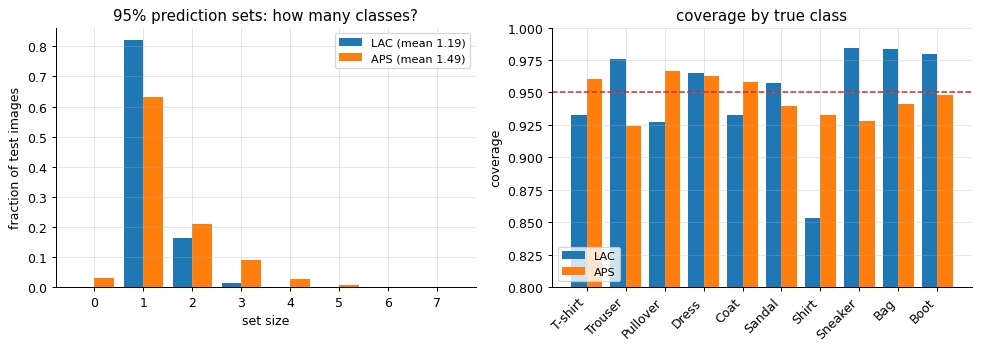

In [15]:
P, Y = P_cal, Yb
N = len(Y); rows = np.arange(N)
rc = np.random.default_rng(1)
pc = rc.permutation(N); ic, it = pc[:5000], pc[5000:]               # conformal calibration / test halves
U = rc.uniform(size=N)                                               # one uniform per image, for APS
alpha_c = 0.05

order = np.argsort(-P, 1); Ps = np.take_along_axis(P, order, 1)      # classes sorted by probability
cum_before = np.cumsum(Ps, 1) - Ps                                   # mass of the classes ranked above
rank = np.argsort(order, 1); r_y = rank[rows, Y]                     # position of the true class in that order

def lac_sets(alpha):
    s = 1 - P[rows, Y]
    q = conformal_quantile(s[ic], alpha)
    return q, P[it] >= 1 - q                                         # boolean (5000, 10) membership

def aps_sets(alpha):
    s = cum_before[rows, r_y] + U * Ps[rows, r_y]
    q = conformal_quantile(s[ic], alpha)
    incl = (cum_before[it] + U[it, None] * Ps[it]) <= q              # in sorted order
    assert np.all(np.diff(incl.astype(int), axis=1) <= 0)            # always a prefix: the top-L classes
    size = incl.sum(1)
    S = np.zeros_like(incl); S[np.arange(len(it))[:, None], order[it]] = incl
    return q, S

def summary(S):
    covered = S[np.arange(len(it)), Y[it]]
    size = S.sum(1)
    return covered, size

print("alpha | LAC: q_hat  coverage  mean size  empty |  APS: q_hat  coverage  mean size  empty")
sets = {}
for a in (0.1, 0.05, 0.02):
    (ql, Sl), (qa, Sa) = lac_sets(a), aps_sets(a)
    (cl, zl), (ca, za) = summary(Sl), summary(Sa)
    sets[a] = dict(lac=(ql, Sl, cl, zl), aps=(qa, Sa, ca, za))
    print(f" {a:.2f} |      {ql:.3f}     {cl.mean():.3f}      {zl.mean():.3f}  {np.mean(zl == 0):.3f} |"
          f"       {qa:.3f}     {ca.mean():.3f}      {za.mean():.3f}  {np.mean(za == 0):.3f}")
q_lac, S_lac, cov_lac, size_lac = sets[alpha_c]["lac"]
q_aps, S_aps, cov_aps, size_aps = sets[alpha_c]["aps"]
assert abs(cov_lac.mean() - 0.95) < 0.015 and abs(cov_aps.mean() - 0.95) < 0.015
acc_it = np.mean(P[it].argmax(1) == Y[it])
print(f"alpha = 0.05: LAC keeps every class with p >= 1 - q_hat = {1 - q_lac:.3f}; top-1 accuracy on these images {acc_it:.3f}")
cls_lac = np.array([cov_lac[Y[it] == c].mean() for c in range(10)])
cls_aps = np.array([cov_aps[Y[it] == c].mean() for c in range(10)])
print("coverage by class (LAC):", np.round(cls_lac, 3))
print("coverage by class (APS):", np.round(cls_aps, 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]; sz = np.arange(0, 8)
ax.bar(sz - 0.2, [np.mean(size_lac == k) for k in sz], width=0.4, color="tab:blue", label=f"LAC (mean {size_lac.mean():.2f})")
ax.bar(sz + 0.2, [np.mean(size_aps == k) for k in sz], width=0.4, color="tab:orange", label=f"APS (mean {size_aps.mean():.2f})")
ax.set_xlabel("set size"); ax.set_ylabel("fraction of test images"); ax.set_title("95% prediction sets: how many classes?"); ax.legend(fontsize=9)
ax = axes[1]
ax.bar(np.arange(10) - 0.2, cls_lac, width=0.4, color="tab:blue", label="LAC")
ax.bar(np.arange(10) + 0.2, cls_aps, width=0.4, color="tab:orange", label="APS")
ax.axhline(0.95, color="tab:red", ls="--", lw=1.2); ax.set_ylim(0.8, 1.0)
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_ylabel("coverage"); ax.set_title("coverage by true class"); ax.legend(fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()

**Interpretation.**
- Both methods deliver the 95% they promise: 0.949 for LAC and 0.946 for APS, on 5,000 images the calibration never saw. The top-1 prediction alone is right 0.888 of the time; the sets buy the extra 6 points by adding a second or third class where the model hesitates.
- LAC gives the smaller sets (mean 1.19, 82% singletons); APS gives larger ones (mean 1.49). Read the table for other levels: at 90% LAC sets are almost all singletons, and some are **empty**, a sign that the image is unlike anything confidently known; at 98% the sets grow.
- The difference is in the right panel: LAC covers Shirt only 0.853 of the time but Trouser 0.976. A threshold on $\hat p_y$ is easy to pass for easy classes and hard for ambiguous ones. APS spreads the coverage much more evenly (from 0.924 to 0.966), because a hesitant model accumulates mass slowly and gets larger sets.
- The set size is itself an uncertainty signal, with a meaning a probability does not have: "with 95% confidence it is one of these".

### 8c. Ambiguous images get large sets

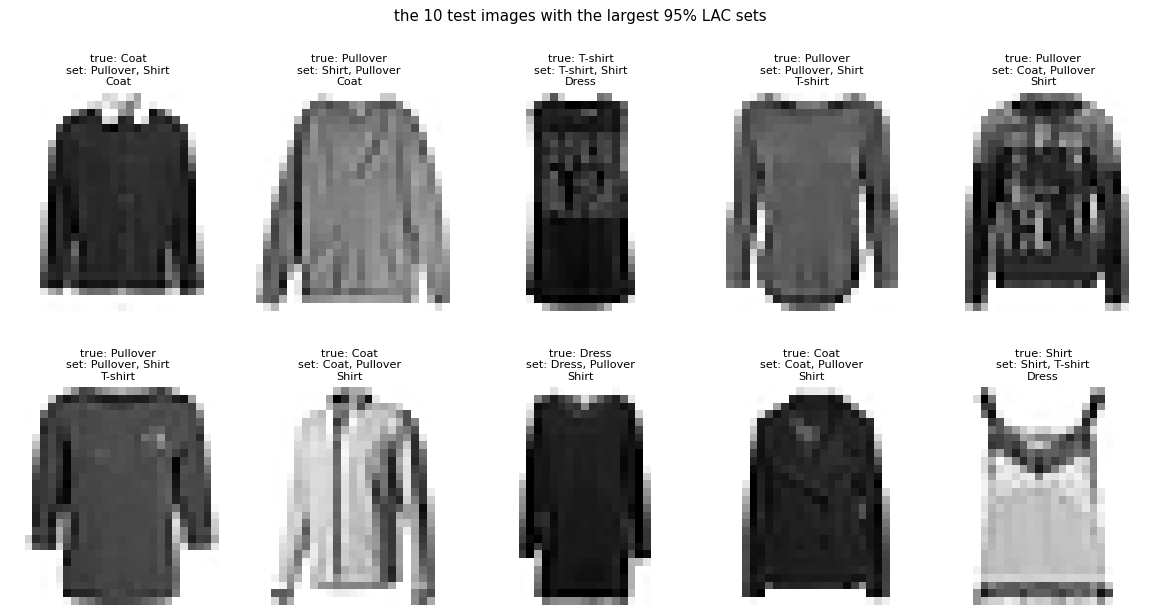

most frequent two-class sets: [(('Shirt', 'T-shirt'), 230), (('Coat', 'Pullover'), 177), (('Pullover', 'Shirt'), 100), (('Coat', 'Shirt'), 78), (('Boot', 'Sneaker'), 49)]
LAC set sizes on the test half: [   1 4109  817   73    0] (sizes 0 to 4)


In [16]:
big = np.argsort(-size_lac, kind="stable")[:10]
fig, axes = plt.subplots(2, 5, figsize=(13, 7.2))
for ax, j in zip(axes.flat, big):
    i = it[j]
    ax.imshow(Xb[i].reshape(28, 28), cmap="gray_r"); ax.axis("off")
    members = [CLASSES[k] for k in np.argsort(-P[i]) if S_lac[j, k]]
    ax.set_title(f"true: {CLASSES[Y[i]]}\nset: " + ", ".join(members[:2]) + ("\n" + ", ".join(members[2:]) if len(members) > 2 else ""), fontsize=9)
plt.suptitle("the 10 test images with the largest 95% LAC sets", y=1.0); plt.tight_layout(h_pad=2.5); plt.show()
pairs = {}
for j in np.where(size_lac == 2)[0]:
    key = tuple(sorted(CLASSES[k] for k in np.where(S_lac[j])[0])); pairs[key] = pairs.get(key, 0) + 1
print("most frequent two-class sets:", sorted(pairs.items(), key=lambda kv: -kv[1])[:5])
print(f"LAC set sizes on the test half: {np.bincount(size_lac, minlength=5)[:5]} (sizes 0 to 4)")

**Things to notice.** The large sets are on images a person would also hesitate on: tops that could be a shirt, a T-shirt, a pullover or a coat. The most frequent two-class sets are the pairs every confusion matrix of Fashion-MNIST shows (Shirt / T-shirt: 230, Coat / Pullover: 177, Pullover / Shirt: 100). Shoes, trousers and bags almost always get a single class.

### 8d. Class-conditional (Mondrian) conformal

The guarantee averages over classes, and section 8b showed LAC under-covering shirts. **Class-conditional** conformal calibrates each class separately: $\hat q_c$ is computed from the scores of the calibration images of class $c$ only, and $C(x) = \{k : s(x, k) \le \hat q_k\}$. Within one class the data are still exchangeable, so the proof of section 5 gives, for every class,

$$
P\big(Y \in C(X) \mid Y = c\big) \ge 1 - \alpha .
$$

The price: about 500 calibration images per class instead of 5,000, so each $\hat q_c$ is noisier and the sets grow a little. The same idea, "Mondrian" conformal, works for any groups decided in advance: regions, age bands, customer segments.

calibration images per class: [468 501 493 518 497 485 509 500 527 502]
threshold 1 - q_c per class:  [0.139 0.985 0.139 0.113 0.184 0.488 0.052 0.732 0.806 0.548]
marginal LAC: coverage 0.949, mean size 1.192, worst class 0.853 (Shirt)
Mondrian LAC: coverage 0.949, mean size 1.320, worst class 0.914 (Trouser)
coverage by class, Mondrian: [0.962 0.914 0.949 0.977 0.934 0.936 0.963 0.944 0.956 0.954]
average over 200 splits, LAC:      [0.93  0.984 0.93  0.949 0.939 0.966 0.856 0.987 0.976 0.979]
average over 200 splits, Mondrian: [0.951 0.953 0.948 0.952 0.949 0.952 0.951 0.95  0.95  0.95 ]


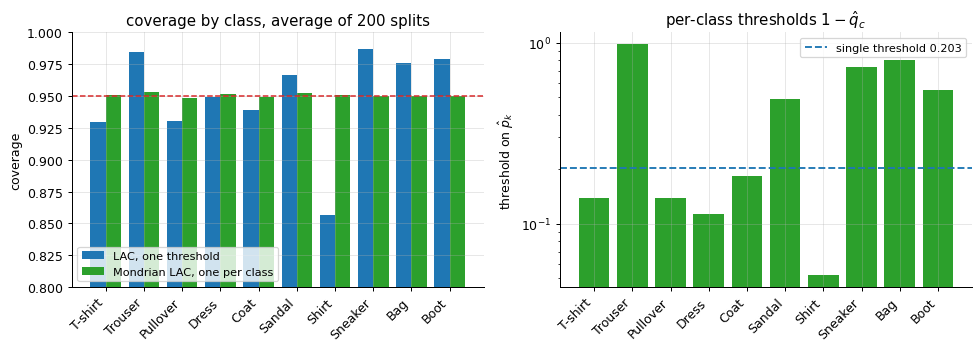

In [17]:
s_lac_all = 1 - P[rows, Y]
q_cls = np.array([conformal_quantile(s_lac_all[ic][Y[ic] == c], alpha_c) for c in range(10)])
S_mon = P[it] >= 1 - q_cls[None, :]                                  # class k is in the set if p_k >= 1 - q_k
cov_mon, size_mon = S_mon[np.arange(len(it)), Y[it]], S_mon.sum(1)
cls_mon = np.array([cov_mon[Y[it] == c].mean() for c in range(10)])
print("calibration images per class:", np.bincount(Y[ic], minlength=10))
print("threshold 1 - q_c per class: ", np.round(1 - q_cls, 3))
print(f"marginal LAC: coverage {cov_lac.mean():.3f}, mean size {size_lac.mean():.3f}, worst class {cls_lac.min():.3f} ({CLASSES[cls_lac.argmin()]})")
print(f"Mondrian LAC: coverage {cov_mon.mean():.3f}, mean size {size_mon.mean():.3f}, worst class {cls_mon.min():.3f} ({CLASSES[cls_mon.argmin()]})")
print("coverage by class, Mondrian:", np.round(cls_mon, 3))

# one split is one draw: average the per-class coverage over 200 random calibration/test splits of the 10,000 images
rs = np.random.default_rng(2); avg_lac, avg_mon = np.zeros(10), np.zeros(10)
for _ in range(200):
    pp = rs.permutation(N); a_, b_ = pp[:5000], pp[5000:]
    ql = conformal_quantile(s_lac_all[a_], alpha_c)
    qc = np.array([conformal_quantile(s_lac_all[a_][Y[a_] == c], alpha_c) for c in range(10)])
    inl, inm = P[b_, Y[b_]] >= 1 - ql, P[b_, Y[b_]] >= 1 - qc[Y[b_]]
    avg_lac += np.array([inl[Y[b_] == c].mean() for c in range(10)]) / 200
    avg_mon += np.array([inm[Y[b_] == c].mean() for c in range(10)]) / 200
print("average over 200 splits, LAC:     ", np.round(avg_lac, 3))
print("average over 200 splits, Mondrian:", np.round(avg_mon, 3))
assert avg_mon.min() >= 0.95 - 0.005

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.bar(np.arange(10) - 0.2, avg_lac, width=0.4, color="tab:blue", label="LAC, one threshold")
ax.bar(np.arange(10) + 0.2, avg_mon, width=0.4, color="tab:green", label="Mondrian LAC, one per class")
ax.axhline(0.95, color="tab:red", ls="--", lw=1.2); ax.set_ylim(0.8, 1.0)
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_ylabel("coverage"); ax.set_title("coverage by class, average of 200 splits"); ax.legend(fontsize=9, loc="lower left")
ax = axes[1]
ax.bar(np.arange(10), 1 - q_cls, color="tab:green"); ax.axhline(1 - q_lac, color="tab:blue", ls="--", label=f"single threshold {1 - q_lac:.3f}")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_ylabel("threshold on $\\hat p_k$"); ax.set_yscale("log")
ax.set_title("per-class thresholds $1 - \\hat q_c$"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** On our split, one threshold per class lifts Shirt from 0.853 to 0.963. The worst class is now Trouser at 0.914: with about 500 calibration and 500 test images per class, the realised coverage of one class on one split fluctuates by more than a point (sd ≈ 0.014). The guarantee is an average over calibration sets, and averaged over 200 random splits every class gets between 0.948 and 0.953 with Mondrian (0.95 up to Monte Carlo noise), against 0.856 for Shirt with a single threshold. The shirt threshold is the lowest of all, 0.052 against a single threshold of 0.203: the model is rarely sure about shirts, so a shirt must enter the set even at a low probability. The average set grows only from 1.19 to 1.32 classes.

## 9. When exchangeability breaks: distribution shift and adaptive conformal inference

Every guarantee above rests on one assumption: the test point is exchangeable with the calibration points. Deploy a model and the world moves: new customers, new sensors, inflation, a pandemic. We break the assumption three ways.

### 9a. Covariate shift and noise shift in regression

We keep the three calibrated intervals of section 6 and test them on (i) points with $X \sim \mathcal{U}(3.5, 5)$ only, the noisy end (**covariate shift**: $P(X)$ changes, $P(Y \mid X)$ does not), and (ii) points from the original $X$ distribution with 1.5 times more noise (**concept shift**: $P(Y \mid X)$ changes).

test data      | constant  normalised   CQR
no shift       |   0.901      0.913     0.907
X ~ U(3.5, 5)  |   0.769      0.902     0.872
noise x 1.5    |   0.791      0.749     0.746


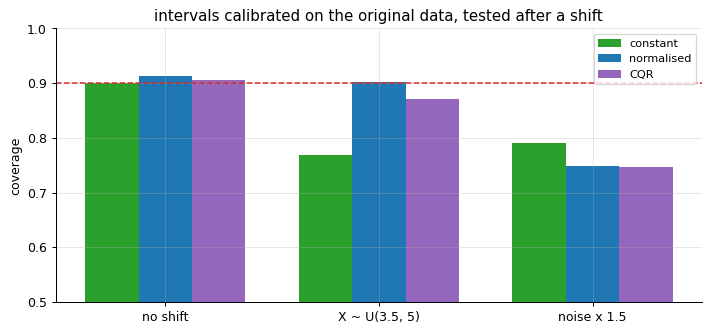

In [18]:
r9 = np.random.default_rng(9)
shift_data = {"no shift": (x_test, y_test), "X ~ U(3.5, 5)": make_data(20000, r9, lo=3.5, hi=5.0),
              "noise x 1.5": make_data(20000, r9, noise_mult=1.5)}
def covers(x, y):
    mu, sd = predict_het(het_net, x); Q = predict_q(qnet, x)
    return {"constant": np.abs(y - mu) <= q_abs, "normalised": np.abs(y - mu) / sd <= q_norm,
            "CQR": np.maximum(Q[:, 0] - y, y - Q[:, 2]) <= q_cqr}
shift_cov = {k: {m: v.mean() for m, v in covers(*xy).items()} for k, xy in shift_data.items()}
print("test data      | constant  normalised   CQR")
for k, d in shift_cov.items():
    print(f"{k:14s} |   {d['constant']:.3f}      {d['normalised']:.3f}     {d['CQR']:.3f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
for j, (m, c) in enumerate((("constant", "tab:green"), ("normalised", "tab:blue"), ("CQR", "tab:purple"))):
    ax.bar(np.arange(3) + (j - 1) * 0.25, [shift_cov[k][m] for k in shift_data], width=0.25, color=c, label=m)
ax.axhline(0.9, color="tab:red", ls="--", lw=1.2); ax.set_ylim(0.5, 1.0)
ax.set_xticks(range(3)); ax.set_xticklabels(list(shift_data)); ax.set_ylabel("coverage"); ax.set_title("intervals calibrated on the original data, tested after a shift"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** Under covariate shift towards the noisy end, the constant band drops to 0.769, while the adaptive ones stay close to 90% (0.902 and 0.872): an interval that is approximately right at every $x$ survives a change in the mix of $x$. More noise for the same $x$ breaks all three (0.791, 0.749, 0.746): nothing calibrated on the past can know the noise has grown. (Under a known covariate shift, *weighted* conformal prediction reweights the calibration scores by $p_{\text{test}}(x)/p_{\text{cal}}(x)$ and restores the guarantee; Tibshirani et al., 2019.)

### 9b. Corrupted images

The Fashion-MNIST sets of section 8 meet test images with Gaussian pixel noise of increasing standard deviation, with the thresholds calibrated on clean images.

pixel noise sd 0.0: accuracy 0.888 | 95% LAC sets: coverage 0.949, mean size 1.19, empty 0.000
pixel noise sd 0.1: accuracy 0.844 | 95% LAC sets: coverage 0.916, mean size 1.24, empty 0.000
pixel noise sd 0.2: accuracy 0.690 | 95% LAC sets: coverage 0.778, mean size 1.29, empty 0.000
pixel noise sd 0.3: accuracy 0.530 | 95% LAC sets: coverage 0.602, mean size 1.27, empty 0.001
pixel noise sd 0.4: accuracy 0.408 | 95% LAC sets: coverage 0.474, mean size 1.27, empty 0.000


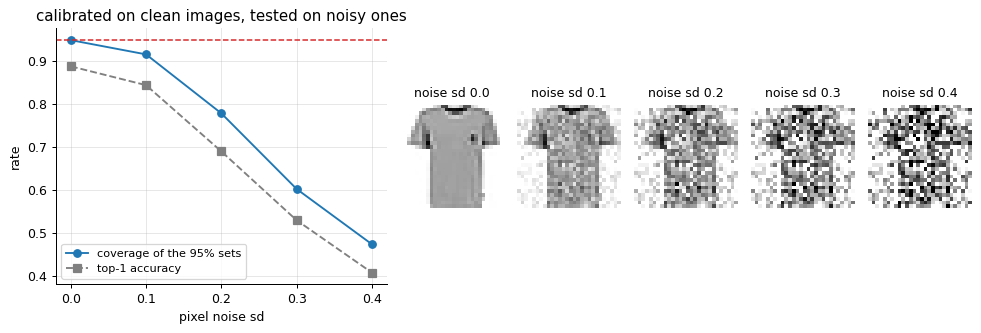

In [19]:
r9b = torch.Generator().manual_seed(9)
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4]
noise_res = []
for sd in noise_levels:
    Xn = (Xb[it] + sd * torch.randn(Xb[it].shape, generator=r9b)).clamp(0, 1)
    with torch.no_grad():
        Pn = F.softmax(clf(Xn.to(device)).cpu().double() / T_hat, 1).numpy()
    Sn = Pn >= 1 - q_lac
    noise_res.append((np.mean(Pn.argmax(1) == Y[it]), Sn[np.arange(len(it)), Y[it]].mean(), Sn.sum(1).mean(), np.mean(Sn.sum(1) == 0)))
    print(f"pixel noise sd {sd:.1f}: accuracy {noise_res[-1][0]:.3f} | 95% LAC sets: coverage {noise_res[-1][1]:.3f}, mean size {noise_res[-1][2]:.2f}, empty {noise_res[-1][3]:.3f}")
noise_res = np.array(noise_res)

fig = plt.figure(figsize=(11, 3.8))
gs = fig.add_gridspec(1, 6, width_ratios=[3.2, 1, 1, 1, 1, 1])
axes = [fig.add_subplot(gs[0])]
axes[0].plot(noise_levels, noise_res[:, 1], "o-", color="tab:blue", label="coverage of the 95% sets")
axes[0].plot(noise_levels, noise_res[:, 0], "s--", color="gray", label="top-1 accuracy")
axes[0].axhline(0.95, color="tab:red", ls="--", lw=1.2); axes[0].set_xlabel("pixel noise sd"); axes[0].set_ylabel("rate"); axes[0].legend(fontsize=9)
axes[0].set_title("calibrated on clean images, tested on noisy ones")
i0 = it[np.where(Y[it] == 0)[0][0]]                                   # the first T-shirt of the test half
for j, sd in enumerate(noise_levels):
    ax = fig.add_subplot(gs[j + 1])
    ax.imshow((Xb[i0] + sd * torch.randn(784, generator=torch.Generator().manual_seed(1))).clamp(0, 1).reshape(28, 28).numpy(), cmap="gray_r")
    ax.axis("off"); ax.set_title(f"noise sd {sd}", fontsize=10)
plt.tight_layout(); plt.show()

**Interpretation.** With noisy pixels the accuracy falls from 0.888 to 0.408 and the coverage of the "95%" sets falls with it, to 0.474 at noise 0.4. The sets do grow a little (mean size 1.19 → 1.27), but nowhere near enough: the network becomes wrong *and* confident. Conformal prediction is not a detector of distribution shift; monitor the coverage on fresh labelled data, and recalibrate.

### 9c. A drifting time series and adaptive conformal inference (ACI)

Points now arrive one at a time. After $t = 1000$ the noise level ramps up, reaching twice its value at $t = 1500$, and stays there. Three strategies, all with target 90%, all with the network of section 2 as the model:

- **fixed**: calibrate once, on the first 500 points;
- **rolling**: recalibrate at every step on the last 500 points;
- **ACI** (Gibbs and Candès, 2021): rolling, plus a feedback loop on the level used. With $\mathrm{err}_t = 1$ if $y_t \notin C_t(x_t)$ and 0 otherwise,

$$
\alpha_{t+1} = \alpha_t + \gamma\,(\alpha - \mathrm{err}_t), \qquad \gamma = 0.005 .
$$

A miss lowers $\alpha_t$ by $\gamma(1-\alpha)$ (wider intervals); a hit raises it by $\gamma\alpha$. Whatever the data do, even adversarially, the long-run miss rate converges to $\alpha$:
$\big|\frac{1}{T}\sum_{t} \mathrm{err}_t - \alpha\big| \le \frac{\max(\alpha_1, 1 - \alpha_1) + \gamma}{\gamma T}$.

fixed   : coverage over t = 500..2999 0.743 | t = 500..999 (stable) 0.910 | t >= 1500 (after the drift) 0.675
rolling : coverage over t = 500..2999 0.878 | t = 500..999 (stable) 0.900 | t >= 1500 (after the drift) 0.887
ACI     : coverage over t = 500..2999 0.900 | t = 500..999 (stable) 0.894 | t >= 1500 (after the drift) 0.909
alpha_t ranged from 0.029 to 0.132
ACI: |miss rate - alpha| = 0.0004 <= bound 0.0724


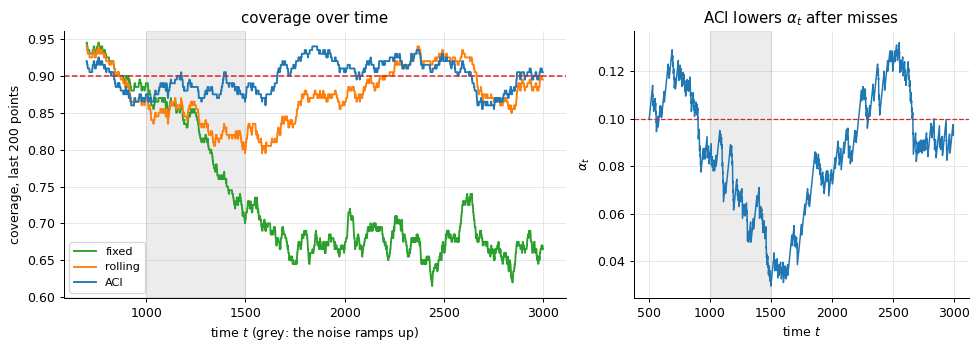

In [20]:
T_len, W, gamma = 3000, 500, 0.005
r9c = np.random.default_rng(5)
tt = np.arange(T_len)
mult = np.where(tt < 1000, 1.0, np.where(tt < 1500, 1 + (tt - 1000) / 500, 2.0))   # noise multiplier over time
xs = r9c.uniform(0, 5, T_len)
ys = f_true(xs) + mult * sigma_true(xs) * r9c.standard_normal(T_len)
S_t = np.abs(ys - predict_het(het_net, xs)[0])

def q_level(scores, a):
    if a <= 0: return np.inf                       # alpha_t <= 0: the whole real line
    if a >= 1: return -np.inf                      # alpha_t >= 1: the empty set
    return conformal_quantile(scores, a)

q_fixed = conformal_quantile(S_t[:W], alpha)
err = {"fixed": [], "rolling": [], "ACI": []}; alpha_t, alphas, widths = alpha, [], []
for t in range(W, T_len):
    win = S_t[t - W:t]
    err["fixed"].append(S_t[t] > q_fixed)
    err["rolling"].append(S_t[t] > conformal_quantile(win, alpha))
    qa = q_level(win, alpha_t); e = S_t[t] > qa
    err["ACI"].append(e); alphas.append(alpha_t); widths.append(2 * qa)
    alpha_t += gamma * (alpha - e)
err = {k: np.array(v, dtype=float) for k, v in err.items()}
aci_cov = {}
for k, e in err.items():
    c = 1 - e
    aci_cov[k] = (c.mean(), c[:500].mean(), c[1000:].mean())
    print(f"{k:8s}: coverage over t = 500..2999 {c.mean():.3f} | t = 500..999 (stable) {c[:500].mean():.3f} | t >= 1500 (after the drift) {c[1000:].mean():.3f}")
print(f"alpha_t ranged from {min(alphas):.3f} to {max(alphas):.3f}")
bound = (max(alpha, 1 - alpha) + gamma) / (gamma * len(err["ACI"]))
assert abs(err["ACI"].mean() - alpha) <= bound
print(f"ACI: |miss rate - alpha| = {abs(err['ACI'].mean() - alpha):.4f} <= bound {bound:.4f}")

def rolling(v, w=200):
    return np.convolve(v, np.ones(w) / w, mode="valid")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]; tx_ = np.arange(W + 199, T_len)
for k, c in (("fixed", "tab:green"), ("rolling", "tab:orange"), ("ACI", "tab:blue")):
    ax.plot(tx_, rolling(1 - err[k]), c, lw=1.5, label=k)
ax.axhline(0.9, color="tab:red", ls="--", lw=1.2); ax.axvspan(1000, 1500, color="gray", alpha=0.15)
ax.set_xlabel("time $t$ (grey: the noise ramps up)"); ax.set_ylabel("coverage, last 200 points"); ax.set_title("coverage over time"); ax.legend(fontsize=9, loc="lower left")
ax = axes[1]
ax.plot(np.arange(W, T_len), alphas, "tab:blue", lw=1.2); ax.axhline(alpha, color="tab:red", ls="--", lw=1)
ax.axvspan(1000, 1500, color="gray", alpha=0.15); ax.set_xlabel("time $t$"); ax.set_ylabel(r"$\alpha_t$"); ax.set_title(r"ACI lowers $\alpha_t$ after misses")
plt.tight_layout(); plt.show()

**Interpretation.** Before the drift all three cover about 90%. After it the fixed interval collapses to 0.675; recalibrating on a rolling window recovers, with a lag, but averages 0.878 overall; ACI keeps 0.900 overall and 0.909 after the drift by temporarily asking for more than 90% (its $\alpha_t$ dips to 0.029) until the window has caught up. ACI does not make the data exchangeable again; it gives a different, weaker guarantee, on the average miss rate over time, which holds for any sequence.

## 10. Summary

- **Two uncertainties**: aleatoric (noise in $Y \mid X$, does not shrink with data) and epistemic (model uncertainty, shrinks with data). A **confidence interval** is for the mean $f(x)$ and shrinks like $1/\sqrt n$ (0.552 → 0.182 from $n$ = 100 to 1,000); a **prediction interval** is for a new $Y$ and contains the noise.
- **Model-based intervals**: a heteroscedastic Gaussian network trained with the NLL $\tfrac12\log\hat\sigma^2 + (y - \hat\mu)^2/(2\hat\sigma^2)$ (covered 0.896 here); quantile regression with the pinball loss $\rho_\tau(u) = \max(\tau u, (\tau-1)u)$, minimised by the $\tau$-quantile (0.881 and 0.856 instead of 0.9); deep ensembles and MC dropout split the variance into aleatoric + epistemic. Useful, but none is guaranteed.
- **Calibration**: reliability diagram and ECE; temperature scaling, one scalar fitted on validation data ($T =$ 1.59, ECE 0.0368 → 0.0155), leaves the accuracy unchanged.
- **Split conformal**: scores on a calibration set, $\hat q$ = the $\lceil (n+1)(1-\alpha)\rceil$-th smallest, $C(x) = \{y : s(x, y) \le \hat q\}$. Under exchangeability $1 - \alpha \le P(Y \in C(X)) \le 1 - \alpha + 1/(n+1)$, by the rank argument. Over calibration sets the coverage is $\mathrm{Beta}(k, n+1-k)$: sd 0.063 for $n = 20$, 0.0103 for $n = 1000$.
- **Marginal, not conditional**: the constant band covered 1.00 to 0.71 across bins of $x$. Normalised scores $|y - \hat\mu|/\hat\sigma$ and **CQR** keep the guarantee and adapt the width (worst bin 0.89 and 0.86). On California housing, CQR covered 0.911 with mean width 1.367 against 1.407 for the constant band.
- **Classification**: LAC $1 - \hat p_y$ (smallest sets, 1.19 classes on average at 95%) and APS (cumulative mass, more even coverage across classes). Set size = uncertainty. Mondrian calibration gives a guarantee per class (Shirt 0.853 → 0.963 on one split; every class ≈ 0.95 on average).
- **Exchangeability breaks**: covariate shift hurts constant bands most; more noise, corrupted inputs or drift break every static method (fixed calibration: 0.675 after the drift). Recalibrate, monitor, or adapt online with ACI (0.900 overall).
- **Libraries**: MAPIE and crepes implement all of this (plus jackknife+ and cross-conformal, which reuse the training data instead of holding out a calibration set). Total runtime of this notebook: 41 s on CPU.

## Exercises

Try each one before opening the answer.

1. **Why $n + 1$.** With $n$ calibration scores, suppose we used the plain empirical quantile, the $\lceil n(1-\alpha) \rceil$-th smallest score. What is the exact coverage for $n = 10$, $\alpha = 0.1$? For $n = 1000$? Is the correction important?
2. **Small calibration sets.** What is the smallest $n$ for which split conformal gives a finite 99% interval? With that $n$, what is the coverage guaranteed by the theorem, and what is the standard deviation of the coverage of one calibrated interval?
3. **Pinball loss.** Show that for $\tau = 0.5$ minimising the pinball loss is the same as minimising the mean absolute error. Then compute by hand the minimiser of the mean pinball loss with $\tau = 0.75$ on the sample $\{1, 2, 3, 10\}$.
4. **Randomised APS.** Without the $U$ term, the APS score of an image is the cumulative mass up to *and including* its true class. Explain why, for a confident and accurate classifier, the 95% quantile of these scores is almost 1, and what that does to the sets. Check it in section 8b by setting `U[:] = 1`.
5. **A negative CQR correction.** In section 6 the CQR correction $\hat q$ was small. When is it negative? What does a negative $\hat q$ do to the interval, and what does it say about the quantile model?
6. **Mondrian cost.** In class-conditional conformal at $\alpha = 0.05$, what is the minimum number of calibration images of a class needed for a finite threshold? If a rare class has only 10 calibration images, what happens to its sets?
7. **ACI step size.** In section 9c, what happens with $\gamma = 0$? With a very large $\gamma$, say 0.5? Use the bound on the long-run miss rate and the formula of the update to explain the trade-off.

<details>
<summary><b>Answers</b></summary>

**1.** By the rank argument the coverage is $k/(n+1)$ for any fixed rank $k$. The plain quantile uses $k = \lceil n(1 - \alpha) \rceil$: for $n = 10$, $k = 9$ and the coverage is $9/11 = 0.818$ instead of at least 0.9 (the corrected $k = 10$ gives $10/11 = 0.909$). For $n = 1000$, $k = 900$ and the coverage is $900/1001 = 0.8991$, against $901/1001 = 0.9001$ with the correction. The correction matters for small calibration sets and is harmless for large ones, so always use it.

**2.** A finite $\hat q$ needs $k = \lceil (n+1)(1-\alpha) \rceil \le n$, i.e. $(n+1)\,0.99 \le n$, i.e. $n \ge 99$. With $n = 99$, $k = \lceil 99 \rceil = 99$: $\hat q$ is the largest score, and the coverage is exactly $99/100 = 0.99$ (the upper bound $1 - \alpha + 1/(n+1) = 1$ is not reached because $k/(n+1) = 0.99$). The coverage of one calibrated interval is $\mathrm{Beta}(99, 1)$, with mean 0.99 and standard deviation $\sqrt{0.99 \times 0.01/101} \approx 0.0099$: about one percentage point, so a given interval can easily cover only 97 or 98%.

**3.** $\rho_{0.5}(u) = \max(u/2, -u/2) = |u|/2$, so the mean pinball loss at $\tau = 0.5$ is half the mean absolute error, with the same minimiser (the median). For $\tau = 0.75$ on $\{1, 2, 3, 10\}$: the minimiser is the empirical quantile $F_n^{-1}(0.75)$, the smallest value with $F_n \ge 0.75$, which is 3 ($F_n(3) = 3/4$). In fact with $n\tau = 3$ an integer the minimum is flat on $[3, 10]$: for $q$ in that interval the derivative $F_n(q) - \tau = 0.75 - 0.75 = 0$. Check: at $q = 3$, the loss is $\frac14\big(0.25 \times 2 + 0.25 \times 1 + 0 + 0.75 \times 7\big) = \frac14 \times 6 = 1.5$; at $q = 10$, $\frac14 \times 0.25 \times (9 + 8 + 7) = 1.5$; at $q = 2$, $\frac14(0.25 + 0 + 0.75 + 6) = 1.75$.

**4.** For a confident and accurate classifier most calibration images have their true class ranked first with $\hat p_y \approx 1$, so the non-randomised score $\sum_{j \text{ ranked} \le y}\hat p_j$ is almost 1 for them, and the misclassified images have scores even closer to 1. The 95% quantile of the scores is then something like 0.9999, and the set must accumulate mass up to 0.9999: it includes the top class and then many classes of negligible probability, often all ten. With `U[:] = 1` in section 8b the APS sets become much larger and the coverage jumps far above 95%: valid, but useless. The term $U\hat p_y$ replaces the full mass of the true class by a uniform fraction of it, which makes the score continuous and the coverage close to exactly $1 - \alpha$.

**5.** $\hat q \lt 0$ when more than about $1 - \alpha$ of the calibration points fall strictly inside the raw quantile band: the band over-covers. Then $C(x) = [\hat q_{\alpha/2}(x) + |\hat q|,\ \hat q_{1-\alpha/2}(x) - |\hat q|]$ shrinks the band from both sides until the calibration coverage is right. It says the quantile model is too cautious, for example because of strong regularisation, too few trees, or because it was trained for a level more extreme than needed. In section 6 the raw band covered slightly less than 90%, so $\hat q$ was positive and small.

**6.** A finite class threshold needs $\lceil (n_c + 1)(1 - \alpha) \rceil \le n_c$, i.e. $n_c \ge 1/\alpha - 1 = 19$ images of that class. With $n_c = 10$, $k = \lceil 11 \times 0.95 \rceil = 11 \gt 10$, so $\hat q_c = +\infty$: the threshold on $\hat p_c$ is $1 - \infty$, every image gets class $c$ in its set, and the sets of the whole dataset grow by one class. In practice: merge rare classes into one group for calibration, or accept a lower level for them.

**7.** With $\gamma = 0$, $\alpha_t = \alpha$ forever: ACI is the rolling method, with no feedback, and the bound $(\ldots)/(\gamma T)$ is infinite: no guarantee under drift. A large $\gamma$ reacts within a few points: the long-run miss rate is guaranteed to be very close to $\alpha$ (the bound shrinks like $1/\gamma$), but $\alpha_t$ jumps by $0.45$ after each miss, so the intervals swing between very wide (often infinite, when $\alpha_t \le 0$) and very narrow. The coverage is right on average but each interval is erratic and uninformative. Small $\gamma$ (0.001 to 0.01) gives stable intervals that adapt over hundreds of steps; it is the usual choice.

</details>